# Preparations

Compare IO-author classification within a campaign and on a completely held-out campaign. The transductive section also summarizes saved Step 3 classification sweeps and indicator information gain. Cross-campaign evaluation uses leave-one-campaign-out only.

Feature loading and per-campaign normalization retain the existing methodology, including normalization over each complete campaign.

## Imports

In [8]:
from __future__ import annotations

# File system
from pathlib import Path
import json
import time

# Data
import pandas as pd
import numpy as np
from scipy.stats import ttest_rel

# Plotting
import matplotlib.pyplot as plt

# sklearn and models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedGroupKFold,
    StratifiedShuffleSplit,
    cross_validate,
)
from xgboost import XGBClassifier

# Utilities
from tqdm.auto import tqdm
from matplotlib.lines import Line2D
from IPython.display import display

## Parameters

Papermill injects overrides into the tagged cell below. Training fractions and ROC_TRAIN_FRACTION apply only to within-campaign evaluation.

In [9]:
# Campaigns - each must have a completed step-3 sweep run at the standard location
CAMPAIGNS = ["Iran_1", "UAE", "Venezuela", "China_1", "Cuba", "Russia_1"]

output_dir = "results/Labeled_Datasets/step_4_inter_intra_classification"

# Sweep configuration - used to build each campaign's exact indicator file path
graph_filtering_setting = "all_authors"  # "all_authors" or "graph_authors"
topic_method = "BERTopic_topic_256"  # BERTopic_topic_128, K_Means_topic_124
edge_types = "similarity+text_similarity+interactions"
top_percentage = 100

# Fractions of labeled target-campaign accounts used for training.
FRACTIONS = [0.01, 0.05, 0.10, 0.25, 0.50, 0.80]
ROC_TRAIN_FRACTION = 0.01
N_SPLITS = 5

MODELS = ["xgboost", "random_forest"] # "logistic_regression"
RANDOM_STATE = 42
indicators_configuration = "All"

In [10]:
def get_optimal_f1_threshold(
    y_true: np.ndarray,
    y_score: np.ndarray,
) -> tuple[float, float]:
    """Return the threshold and F1 score that maximize validation F1.

    Args:
        y_true: Binary validation labels.
        y_score: Predicted probabilities or decision scores for class 1.

    Returns:
        Threshold and its corresponding maximum F1 score.
    """
    scores = np.asarray(y_score)
    if scores.ndim == 2:
        scores = scores[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    f1_values = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(precision),
        where=(precision + recall) != 0,
    )
    best_index = int(np.argmax(f1_values[:-1]))
    return float(thresholds[best_index]), float(f1_values[best_index])


def optimized_f1_score(y_true: np.ndarray, y_score: np.ndarray) -> float:
    """Return the maximum F1 score over validation thresholds.

    Args:
        y_true: Binary validation labels.
        y_score: Predicted probabilities or decision scores for class 1.

    Returns:
        Maximum F1 score across the validation thresholds.
    """
    _, best_f1 = get_optimal_f1_threshold(y_true, y_score)
    return best_f1


OPTIMIZED_F1_SCORER = make_scorer(
    optimized_f1_score,
    response_method="predict_proba",
)

SCORING = {
    "auc_roc": "roc_auc",
    "auc_pr": "average_precision",
    "f1": make_scorer(f1_score, zero_division=0),
    "macro_f1": make_scorer(
        f1_score,
        average="macro",
        zero_division=0,
    ),
    "optimized_f1": OPTIMIZED_F1_SCORER,
    "recall": make_scorer(recall_score, zero_division=0),
    "precision": make_scorer(precision_score, zero_division=0),
}
METRIC_COLUMNS = list(SCORING)
print(f"Scoring metrics: {METRIC_COLUMNS}")

Scoring metrics: ['auc_roc', 'auc_pr', 'f1', 'macro_f1', 'optimized_f1', 'recall', 'precision']


In [11]:
def validate_percentage(value: float | int, value_name: str) -> float:
    """Return a percentage after validating the shared 1-100 scale.

    Args:
        value: Percentage value from 1 through 100.
        value_name: Parameter name used in an error message.

    Returns:
        Validated percentage as a float.

    Raises:
        ValueError: If value is outside the inclusive range [1, 100].
    """
    percentage = float(value)
    if not 1 <= percentage <= 100:
        raise ValueError(
            f"{value_name} must be in [1, 100], where 1 means 1%; "
            f"got {value}."
        )
    return percentage

top_percentage = validate_percentage(top_percentage, "top_percentage")

## Paths And Reporting

In [12]:
def find_project_root(start_path):
    """Find the Backbone-Graph project root containing AGENTS.md.

    Args:
        start_path: Directory from which to begin the search.

    Returns:
        Path to the Backbone-Graph project root.
    """
    start_path = Path(start_path).resolve()
    for directory in (start_path, *start_path.parents):
        if (directory / "AGENTS.md").exists():
            return directory
    raise FileNotFoundError("Could not find the Backbone-Graph project root.")

project_root = find_project_root(Path.cwd())
results_root = project_root / "results" / "Labeled_Datasets"
CONFIG_TAG = (
    f"{graph_filtering_setting}_{topic_method}_{edge_types}"
    f"_top_percentage_{top_percentage:g}"
)
output_root = Path(output_dir).expanduser()
if not output_root.is_absolute():
    output_root = project_root / output_root
campaign_group_name = "_".join(sorted(campaign.lower().replace(" ", "_") for campaign in CAMPAIGNS))
top_percentage_output_path = (
    output_root / campaign_group_name / f"top_percentage_{top_percentage:g}"
)
transductive_output_path = top_percentage_output_path / "transductive_within_campaign"
inductive_output_path = top_percentage_output_path / "inductive_cross_campaign"
for folder in (top_percentage_output_path, transductive_output_path, inductive_output_path):
    folder.mkdir(parents=True, exist_ok=True)

In [13]:
def write_report(msg: str) -> None:
    """Print progress and append it to the campaign group's report.

    Args:
        msg: Message to report.
    """
    line = f"{time.strftime('%Y-%m-%d %H:%M:%S')} | {msg}"
    print(line)
    report_path = top_percentage_output_path / "progress_report.txt"
    with report_path.open("a", encoding="utf-8") as report_file:
        report_file.write(line + "\n")



def save_summary(table: pd.DataFrame, output_path: Path, name: str) -> None:
    """Export a summary as CSV and LaTeX.

    Args:
        table: Summary table to export without its index.
        output_path: Destination directory.
        name: Filename without an extension.
    """
    output_path.mkdir(parents=True, exist_ok=True)
    table.to_csv(output_path / f"{name}.csv", index=False)
    table.to_latex(output_path / f"{name}.tex", index=False, float_format="%.3f", escape=True)

In [14]:
def build_indicator_path(campaign: str, graph_filtering_setting: str) -> Path:
    """Build a campaign's step-3 indicator file path from the sweep config.

    Args:
        campaign: Campaign name (matches its results directory name).
        graph_filtering_setting: Graph filtering setting (e.g., "all_authors" or "graph_authors").

    Returns:
        Path to the expected `classification_sweep_indicators` parquet file.
    """
    base_dir = (
        results_root / campaign / f"{campaign}_part_all"
        / "step_3_key_authors_graph" / "classification_sweep"
        / "classification_sweep_indicators" / graph_filtering_setting
    )
    sweep_filename = (
        f"accounts_graph_{topic_method}_{edge_types}"
        f"_top_percentage_{top_percentage:g}_per_topic"
        f"_topic_col_{topic_method}_undirected_indicators.parquet"
    )
    return base_dir / sweep_filename


campaign_base_dirs = {campaign: build_indicator_path(campaign, graph_filtering_setting) for campaign in CAMPAIGNS}

print("Campaigns' paths:")
for campaign, path in campaign_base_dirs.items():
    print(f"  {campaign}: {path}")


for campaign, path in campaign_base_dirs.items():
    if not path.exists():
        raise FileNotFoundError(
            f"No data found for '{campaign}' at: {path}\n"
            f"Has the pipeline completed step 3 for this campaign?"
        )

Campaigns' paths:
  Iran_1: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Iran_1/Iran_1_part_all/step_3_key_authors_graph/classification_sweep/classification_sweep_indicators/all_authors/accounts_graph_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_per_topic_topic_col_BERTopic_topic_256_undirected_indicators.parquet
  UAE: /home/amitner/Backbone-Graph/results/Labeled_Datasets/UAE/UAE_part_all/step_3_key_authors_graph/classification_sweep/classification_sweep_indicators/all_authors/accounts_graph_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_per_topic_topic_col_BERTopic_topic_256_undirected_indicators.parquet
  Venezuela: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Venezuela/Venezuela_part_all/step_3_key_authors_graph/classification_sweep/classification_sweep_indicators/all_authors/accounts_graph_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_per_topic_topic_col_BERTopic_topic

## Data Loading And Classifiers

Labels come from `io_drive_label`, with the existing Step 3 JSON fallback. Shared numeric features exclude labels and campaign identifiers.

In [15]:
def get_classifier(model_name: str, random_state: int = RANDOM_STATE, **kwargs):
    """Return a sklearn-compatible classifier by name.

    Args:
        model_name: One of "xgboost"/"xgb", "random_forest"/"rf",
            "logistic_regression"/"lr".
        random_state: Random seed forwarded to the classifier constructor.
        **kwargs: Additional keyword arguments passed to the constructor.

    Returns:
        An untrained sklearn-compatible classifier instance.

    Raises:
        ValueError: If model_name is not recognised.
    """
    name = model_name.lower()
    if name in ("xgboost", "xgb"):
        return XGBClassifier(
            random_state=random_state,
            eval_metric="logloss",
            n_jobs=1,
            **kwargs,
        )
    if name in ("random_forest", "rf"):
        return RandomForestClassifier(
            random_state=random_state, n_jobs=1, **kwargs
        )
    if name in ("logistic_regression", "lr"):
        return LogisticRegression(
            random_state=random_state,
            solver="liblinear",
            max_iter=1000,
            n_jobs=1,
            **kwargs,
        )
    raise ValueError(
        f"Unsupported model_name: '{model_name}'. "
        "Supported: xgboost/xgb, random_forest/rf, logistic_regression/lr."
    )

In [16]:
def load_campaign_data(
    campaign_name: str,
    indicator_path: str | Path,
    prefix_ids: bool = True,
    normalize: bool = True,
    feature_columns: list[str] | None = None,
) -> tuple[pd.DataFrame, set[str]]:
    """Load one campaign's node indicators and IO-author labels.

    Args:
        campaign_name: Campaign label added to every returned row.
        indicator_path: Path to the campaign indicator parquet file.
        prefix_ids: Whether to prefix author IDs with the campaign name.
        normalize: Whether to min-max normalize numeric features within the
            complete campaign. Constant columns are set to zero.
        feature_columns: Optional ordered numeric feature list.

    Returns:
        A feature DataFrame with a ``campaign_name`` column and the set of IO
        author IDs using the same optional campaign prefix.

    Raises:
        FileNotFoundError: If the indicator file does not exist.
        ValueError: If labels or requested features are unavailable.
    """
    campaign_name = campaign_name.strip()
    path = Path(indicator_path).expanduser()
    if not path.exists():
        raise FileNotFoundError(f"No indicator file for '{campaign_name}' at: {path}")

    df_features = pd.read_parquet(path)
    if "io_drive_label" in df_features.columns:
        io_labels = pd.to_numeric(df_features["io_drive_label"], errors="coerce")
        io_set = set(df_features.index[io_labels.eq(1)].astype(str))
    else:
        step_3_dir = path.parents[3]
        label_paths = sorted(
            step_3_dir.glob(
                "topic_col_*/io_author_analysis/io_authors_by_post_ratio.json"
            )
        )
        if not label_paths:
            raise ValueError(
                f"'{path}' has no 'io_drive_label' column and no "
                "io_author_analysis/io_authors_by_post_ratio.json was found "
                f"below '{step_3_dir}'."
            )
        with open(label_paths[0], encoding="utf-8") as label_file:
            io_set = set(map(str, json.load(label_file)))
        write_report(
            f"'{campaign_name}' has no embedded io_drive_label; "
            f"loaded labels from: {label_paths[0]}"
        )

    df_features = df_features.drop(
        columns=[
            "io_drive_label",
            "louvain_community",
            "top_topic",
            "boost_score",
        ],
        errors="ignore",
    ).select_dtypes(include="number")

    if feature_columns is not None:
        missing_columns = sorted(set(feature_columns) - set(df_features.columns))
        if missing_columns:
            raise ValueError(
                f"'{campaign_name}' is missing shared features: {missing_columns}"
            )
        df_features = df_features[feature_columns].copy()

    if normalize:
        numeric_columns = df_features.columns
        column_min = df_features[numeric_columns].min()
        column_range = (
            df_features[numeric_columns].max() - column_min
        ).replace(0, 1)
        df_features[numeric_columns] = (
            df_features[numeric_columns] - column_min
        ) / column_range

    if prefix_ids:
        df_features.index = campaign_name + "_" + df_features.index.astype(str)
        io_set = {f"{campaign_name}_{author_id}" for author_id in io_set}

    df_features["campaign_name"] = campaign_name
    n_io_in_graph = len(set(df_features.index.astype(str)) & io_set)
    write_report(
        f"Loaded '{campaign_name}' ({path}) | {len(df_features):,} authors "
        f"| {len(io_set):,} IO authors (dataset) "
        f"| {n_io_in_graph:,} IO in graph"
    )
    return df_features, io_set


def load_multiple_campaigns(
    campaign_paths: dict[str, Path],
    feature_columns: list[str] | None = None,
) -> tuple[pd.DataFrame, set[str]]:
    """Load and concatenate multiple campaign feature tables.

    Args:
        campaign_paths: Campaign names mapped to indicator parquet paths.
        feature_columns: Optional ordered numeric feature list.

    Returns:
        Combined feature DataFrame and union of campaign-prefixed IO authors.
    """
    frames = []
    combined_io = set()
    for campaign_name, path in campaign_paths.items():
        campaign_df, io_set = load_campaign_data(
            campaign_name,
            path,
            prefix_ids=True,
            feature_columns=feature_columns,
        )
        frames.append(campaign_df)
        combined_io.update(io_set)
    return pd.concat(frames, axis=0), combined_io

In [17]:
# Use the same feature schema for every train/test campaign combination.
def get_common_numeric_feature_columns(
    campaign_paths: dict[str, Path],
) -> list[str]:
    """Return numeric model features present in every campaign.

    Args:
        campaign_paths: Campaign names mapped to indicator parquet paths.

    Returns:
        Numeric feature names shared by every campaign, in source order.
    """
    excluded_columns = {
        "io_drive_label",
        "louvain_community",
        "top_topic",
        "boost_score",
    }
    numeric_columns_by_campaign = {}
    for campaign_name, path in campaign_paths.items():
        campaign_df = pd.read_parquet(path)
        numeric_columns_by_campaign[campaign_name] = [
            column
            for column in campaign_df.select_dtypes(include="number").columns
            if column not in excluded_columns
        ]

    first_campaign = next(iter(campaign_paths))
    common_columns = set.intersection(
        *(set(columns) for columns in numeric_columns_by_campaign.values())
    )
    ordered_columns = [
        column
        for column in numeric_columns_by_campaign[first_campaign]
        if column in common_columns
    ]
    if not ordered_columns:
        raise ValueError("The selected campaigns have no numeric features in common.")
    return ordered_columns


FEATURE_COLUMNS_USED = get_common_numeric_feature_columns(campaign_base_dirs)
write_report(
    f"Common feature columns used ({len(FEATURE_COLUMNS_USED)}): "
    f"{FEATURE_COLUMNS_USED}"
)

2026-09-06 17:14:03 | Common feature columns used (10): ['degree_centrality', 'harmonic_centrality', 'eigenvector_centrality', 'betweenness_centrality', 'pagerank', 'core_number', 'clustering', 'key_score_sum', 'key_score_dominance', 'posting_dominance']


## Evaluation Helpers

## Plotting Helpers

In [18]:
MODEL_STYLES = {
    "xgboost": ("XGBoost", "-", "o"),
    "random_forest": ("Random Forest", "--", "s"),
    "logistic_regression": ("Logistic Regression", ":", "^"),
}
CAMPAIGN_ORDER = list(campaign_base_dirs)
campaign_palette = plt.get_cmap("tab10")
CAMPAIGN_COLORS = {
    campaign: campaign_palette(index % 10)
    for index, campaign in enumerate(CAMPAIGN_ORDER)
}
METRIC_LABELS = {
    "auc_roc": "ROC AUC",
    "auc_pr": "PR AUC",
    "f1": "F1",
    "macro_f1": "Macro F1",
    "optimized_f1": "Optimized F1",
    "recall": "Recall",
    "precision": "Precision",
}

In [19]:
def plot_campaign_performance(
    results: pd.DataFrame,
    metric: str,
    experiment_type: str,
    model_name: str,
    output_dir: Path | None = None,
) -> None:
    """Plot campaign learning curves and mean ROC curves at the selected training fraction.

    Args:
        results: Split-level experiment results.
        metric: Metric to plot.
        experiment_type: Within-campaign learning setting (transductive).
        model_name: Classifier to include in the figure.
        output_dir: Optional figure directory.
    """
    plot_data = results[
        (results["experiment_type"] == experiment_type)
        & (results["model"] == model_name)
    ]
    represented_campaigns = set(plot_data["target_campaign"])
    campaigns = [
        campaign
        for campaign in CAMPAIGN_ORDER
        if campaign in represented_campaigns
    ]
    if not campaigns:
        write_report(
            f"No data to plot for '{model_name}', '{experiment_type}', "
            f"and '{metric}'."
        )
        return

    required_roc_columns = {"roc_fpr", "roc_tpr"}
    missing_roc_columns = required_roc_columns - set(plot_data.columns)
    if missing_roc_columns:
        raise ValueError(
            "ROC coordinates are missing from the results. Rerun the "
            "experiment sweep before creating this figure."
        )

    figure, (curve_axis, roc_axis) = plt.subplots(
        1,
        2,
        figsize=(28, 14),
        dpi=150,
    )
    for campaign in campaigns:
        campaign_data = plot_data[plot_data["target_campaign"] == campaign]
        summary = (
            campaign_data.groupby("train_fraction")[metric]
            .agg(["mean", "std"])
            .reset_index()
        )
        if summary.empty:
            continue

        means = summary["mean"]
        std = summary["std"].fillna(0)
        error = np.vstack([
            means - np.maximum(means - std, 0),
            np.minimum(means + std, 1) - means,
        ])
        curve_axis.errorbar(
            summary["train_fraction"] * 100,
            means,
            yerr=error,
            color=CAMPAIGN_COLORS[campaign],
            linestyle="-",
            marker="o",
            capsize=3,
            linewidth=2,
            markersize=6,
        )

    learning_label = experiment_type.title()
    model_label = MODEL_STYLES.get(
        model_name,
        (model_name.replace("_", " ").title(), "-", "o"),
    )[0]
    title = (
        f"{model_label} - {METRIC_LABELS[metric]} For All Campaigns - "
        f"{learning_label} Learning"
    )
    filename = (
        f"experiment_results_{CONFIG_TAG}_{model_name}_{experiment_type}_{metric}"
        "_all_campaigns.png"
    )

    percentages = [fraction * 100 for fraction in FRACTIONS]
    y_minimum = 0.9 if metric == "auc_roc" else 0.3
    curve_axis.set(
        xticks=percentages,
        xticklabels=[f"{value:g}%" for value in percentages],
        ylim=(y_minimum, 1.01),
        xlabel="Labeled target training data",
        ylabel=METRIC_LABELS[metric],
    )
    curve_axis.tick_params(axis="both", labelsize=26)
    curve_axis.xaxis.label.set_size(34)
    curve_axis.yaxis.label.set_size(34)
    curve_axis.set_title(
        "Score By Labeled Training Data",
        fontsize=32,
    )
    curve_axis.grid(True, linestyle="--", alpha=0.4)

    common_false_positive_rate = np.linspace(0, 1, 201)
    for campaign in campaigns:
        campaign_roc_data = plot_data.loc[
            plot_data["target_campaign"].eq(campaign)
            & np.isclose(
                plot_data["train_fraction"],
                ROC_TRAIN_FRACTION,
            )
        ]
        interpolated_true_positive_rates = []
        for _, split_row in campaign_roc_data.iterrows():
            false_positive_rate = np.asarray(
                json.loads(split_row["roc_fpr"]),
                dtype=float,
            )
            true_positive_rate = np.asarray(
                json.loads(split_row["roc_tpr"]),
                dtype=float,
            )
            interpolated = np.interp(
                common_false_positive_rate,
                false_positive_rate,
                true_positive_rate,
            )
            interpolated[0] = 0
            interpolated_true_positive_rates.append(interpolated)
        if not interpolated_true_positive_rates:
            continue

        mean_true_positive_rate = np.mean(
            interpolated_true_positive_rates,
            axis=0,
        )
        mean_true_positive_rate[-1] = 1
        mean_auc = campaign_roc_data["auc_roc"].mean()
        roc_axis.plot(
            common_false_positive_rate,
            mean_true_positive_rate,
            color=CAMPAIGN_COLORS[campaign],
            linewidth=3,
            label=f"{campaign.replace('_', ' ')} (AUC = {mean_auc:.3f})",
        )

    roc_axis.plot(
        [0, 1],
        [0, 1],
        color="black",
        linestyle="--",
        linewidth=2,
        label="Random classifier",
    )
    roc_axis.set(
        xlim=(-0.01, 1.01),
        ylim=(-0.01, 1.01),
        xlabel="False positive rate",
        ylabel="True positive rate",
    )
    roc_axis.tick_params(axis="both", labelsize=26)
    roc_axis.xaxis.label.set_size(34)
    roc_axis.yaxis.label.set_size(34)
    roc_axis.set_title(
        f"ROC Curves At {ROC_TRAIN_FRACTION:.0%} Labeled Training Data",
        fontsize=32,
    )
    roc_axis.grid(True, linestyle="--", alpha=0.4)
    roc_axis.legend(fontsize=24, loc="lower right")

    campaign_handles = [
        Line2D([0], [0], color=CAMPAIGN_COLORS[campaign], linewidth=3, label=campaign)
        for campaign in campaigns
    ]
    curve_axis.legend(
        handles=campaign_handles,
        fontsize=26,
        loc="lower right",
        ncol=2,
    )

    figure.suptitle(title, fontsize=21, fontweight="bold")
    figure.text(
        0.5,
        0,
        "Transductive IO classification: Classify IO accounts by learning patterns "
        "from the same campaign/network."
        "\n"
        f"Points show mean +/- one standard deviation, and ROC curves show the mean across {N_SPLITS} stratified splits.",
        ha="center",
        va="bottom",
        fontsize=18,
    )
    figure.tight_layout(rect=[0, 0.15, 1, 0.93], w_pad=3.0)
    if output_dir is not None:
        plot_path = Path(output_dir) / filename
        figure.savefig(plot_path, dpi=600, bbox_inches="tight")
        write_report(f"Saved plot to: {plot_path}")
    plt.show()
    plt.close(figure)

# Transductive Within-Campaign

## Aggregate Saved Classification Sweeps

Compare configurations available across the selected campaigns at the selected top percentage. Preserve the original aggregation rules and report metric availability before averaging.

In [20]:
def get_results_path(project_root, campaign):
    """Build the classification sweep results path for a campaign.

    Args:
        project_root: Root directory of the project.
        campaign: Campaign directory name.

    Returns:
        Path to the campaign's classification sweep CSV file.
    """
    return (
        project_root
        / "results"
        / "Labeled_Datasets"
        / campaign
        / f"{campaign}_part_all"
        / "step_3_key_authors_graph"
        / "classification_sweep"
        / "classification_sweep_results.csv"
    )

### Load Campaign Sweeps

In [21]:
if not CAMPAIGNS:
    raise ValueError("CAMPAIGNS must contain at least one campaign name.")

campaign_results = {}

for campaign in CAMPAIGNS:
    results_path = get_results_path(project_root, campaign)
    campaign_df = pd.read_csv(results_path)
    campaign_df = campaign_df.loc[
        campaign_df["top_percentage"].eq(top_percentage)
    ]
    campaign_df["indicators_configuration"] = campaign_df[
        "indicators_configuration"
    ].str.replace(
        " (Unweighted Clustering, No Square Clustering)",
        "",
        regex=False,
    )
    campaign_results[campaign] = campaign_df

### Configuration Availability

In [22]:
configuration_columns = [
    "topic_col",
    "account_relations_configuration",
    "indicators_configuration",
]
configuration_presence_records = []
common_configuration_values = {}

for configuration_column in configuration_columns:
    values_by_campaign = {
        campaign: set(campaign_df[configuration_column].dropna().unique())
        for campaign, campaign_df in campaign_results.items()
    }
    common_configuration_values[configuration_column] = set.intersection(
        *values_by_campaign.values()
    )
    all_configuration_values = set.union(*values_by_campaign.values())

    for configuration_value in sorted(all_configuration_values):
        present_in = [
            campaign
            for campaign, values in values_by_campaign.items()
            if configuration_value in values
        ]
        missing_from = [
            campaign
            for campaign, values in values_by_campaign.items()
            if configuration_value not in values
        ]
        configuration_presence_records.append(
            {
                "configuration": configuration_column,
                "value": configuration_value,
                "present_in": ", ".join(present_in),
                "missing_from": ", ".join(missing_from) or "None",
                "present_in_all_datasets": not missing_from,
            }
        )

configuration_presence_df = pd.DataFrame(configuration_presence_records)
print("Configuration availability by campaign:")
display(configuration_presence_df)

Configuration availability by campaign:


,configuration,value,present_in,missing_from,present_in_all_datasets
0,topic_col,BERTopic_topic_10,"Iran_1, UAE, Venezuela, China_1, Cuba, Russia_1",None,True
1,topic_col,BERTopic_topic_128,"Iran_1, UAE, Venezuela, China_1, Cuba, Russia_1",None,True
2,topic_col,BERTopic_topic_256,"Iran_1, UAE, Venezuela, China_1, Cuba, Russia_1",None,True
3,topic_col,BERTopic_topic_512,"Iran_1, UAE, Venezuela, China_1, Cuba, Russia_1",None,True
4,topic_col,K_Means_topic_108,Cuba,"Iran_1, UAE, Venezuela, China_1, Russia_1",False
5,topic_col,K_Means_topic_112,China_1,"Iran_1, UAE, Venezuela, Cuba, Russia_1",False
6,topic_col,K_Means_topic_128,Iran_1,"UAE, Venezuela, China_1, Cuba, Russia_1",False
7,topic_col,K_Means_topic_16,"UAE, Russia_1","Iran_1, Venezuela, China_1, Cuba",False
8,topic_col,K_Means_topic_60,Venezuela,"Iran_1, UAE, China_1, Cuba, Russia_1",False
9,account_relations_configuration,interactions,"Iran_1, UAE, Venezuela, China_1, Cuba, Russia_1",None,True


### Metric Availability

In [23]:
requested_summary_metric_columns = {
    "all_authors_auc": "ROC_AUC",
    "all_authors_auc_pr": "PR_AUC",
}
metric_presence_records = []
summary_metric_columns = {}
for metric_column, metric_name in requested_summary_metric_columns.items():
    present_in = [
        campaign
        for campaign, campaign_df in campaign_results.items()
        if metric_column in campaign_df
        and campaign_df[metric_column].notna().any()
    ]
    missing_from = [
        campaign for campaign in CAMPAIGNS if campaign not in present_in
    ]
    metric_presence_records.append(
        {
            "metric": metric_name,
            "source_column": metric_column,
            "present_in": ", ".join(present_in),
            "missing_from": ", ".join(missing_from) or "None",
            "present_in_all_datasets": not missing_from,
        }
    )
    if not missing_from:
        summary_metric_columns[metric_column] = metric_name

metric_presence_df = pd.DataFrame(metric_presence_records)
print("Metric availability by campaign:")
display(metric_presence_df)

Metric availability by campaign:


,metric,source_column,present_in,missing_from,present_in_all_datasets
0,ROC_AUC,all_authors_auc,"Iran_1, UAE, Venezuela, China_1, Cuba, Russia_1",None,True
1,PR_AUC,all_authors_auc_pr,"Iran_1, UAE, Venezuela, China_1, Cuba, Russia_1",None,True


### Detailed Averages

In [24]:
all_results_df = pd.concat(campaign_results.values(), ignore_index=True)
for configuration_column, common_values in common_configuration_values.items():
    all_results_df = all_results_df.loc[
        all_results_df[configuration_column].isin(common_values)
    ]
all_results_df = all_results_df.reset_index(drop=True)
group_columns = all_results_df.select_dtypes(exclude="number").columns.tolist()
aggregated_df = (
    all_results_df.groupby(group_columns, as_index=False, dropna=False)
    .mean(numeric_only=True)
    .sort_values(group_columns)
    .reset_index(drop=True)
)

display(aggregated_df)

classification_group_columns = configuration_columns
classification_metric_columns = [
    column
    for column in all_results_df.columns
    if column.startswith(("graph_authors_", "all_authors_"))
    and all(
        column in campaign_df and campaign_df[column].notna().any()
        for campaign_df in campaign_results.values()
    )
]
classification_metrics_df = (
    all_results_df[
        classification_group_columns + classification_metric_columns
    ]
    .groupby(classification_group_columns, as_index=False, dropna=False)
    .mean(numeric_only=True)
    .sort_values(classification_group_columns)
    .reset_index(drop=True)
)

display(classification_metrics_df)

,topic_col,account_relations_configuration,indicators_configuration,model,top_percentage,indicators_runtime_seconds,n_graph_authors,n_all_authors,graph_authors_auc,graph_authors_f1,graph_authors_auc_pr,graph_authors_recall,graph_authors_precision,all_authors_auc,all_authors_f1,all_authors_auc_pr,all_authors_recall,all_authors_precision
0,BERTopic_topic_10,interactions,All,logistic_regression,100.0,75.378501,23040.833333,23040.833333,0.848826,0.594562,0.654030,0.478152,0.856179,0.848826,0.594562,0.654030,0.478152,0.856179
1,BERTopic_topic_10,interactions,All,random_forest,100.0,75.378501,23040.833333,23040.833333,0.952314,0.828934,0.877000,0.731604,0.964657,0.952314,0.828934,0.877000,0.731604,0.964657
2,BERTopic_topic_10,interactions,All,xgboost,100.0,75.378501,23040.833333,23040.833333,0.957196,0.849328,0.876945,0.775821,0.941270,0.957196,0.849328,0.876945,0.775821,0.941270
3,BERTopic_topic_10,interactions,All but Betweenness and Harmonic,logistic_regression,100.0,75.378501,23040.833333,23040.833333,0.846834,0.595324,0.651722,0.478603,0.849954,0.846834,0.595324,0.651722,0.478603,0.849954
4,BERTopic_topic_10,interactions,All but Betweenness and Harmonic,random_forest,100.0,75.378501,23040.833333,23040.833333,0.950365,0.834631,0.876089,0.740620,0.963021,0.950365,0.834631,0.876089,0.740620,0.963021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,BERTopic_topic_512,text_similarity+interactions,All but Betweenness and Harmonic,random_forest,100.0,10470.238580,23040.833333,23040.833333,0.993144,0.967172,0.981409,0.946476,0.989104,0.993144,0.967172,0.981409,0.946476,0.989104
248,BERTopic_topic_512,text_similarity+interactions,All but Betweenness and Harmonic,xgboost,100.0,10470.238580,23040.833333,23040.833333,0.995180,0.968582,0.982783,0.952323,0.985525,0.995180,0.968582,0.982783,0.952323,0.985525
249,BERTopic_topic_512,text_similarity+interactions,Core Number Only,logistic_regression,100.0,10470.238580,23040.833333,23040.833333,0.889676,0.518823,0.562376,0.513343,0.528360,0.889676,0.518823,0.562376,0.513343,0.528360
250,BERTopic_topic_512,text_similarity+interactions,Core Number Only,random_forest,100.0,10470.238580,23040.833333,23040.833333,0.936458,0.640491,0.687305,0.643669,0.752600,0.936458,0.640491,0.687305,0.643669,0.752600


,topic_col,account_relations_configuration,indicators_configuration,graph_authors_auc,graph_authors_f1,graph_authors_auc_pr,graph_authors_recall,graph_authors_precision,all_authors_auc,all_authors_f1,all_authors_auc_pr,all_authors_recall,all_authors_precision
0,BERTopic_topic_10,interactions,All,0.919445,0.757608,0.802658,0.661859,0.920702,0.919445,0.757608,0.802658,0.661859,0.920702
1,BERTopic_topic_10,interactions,All but Betweenness and Harmonic,0.917585,0.759527,0.801386,0.664454,0.918238,0.917585,0.759527,0.801386,0.664454,0.918238
2,BERTopic_topic_10,interactions,Core Number Only,0.776689,0.392803,0.429800,0.306869,0.618418,0.776689,0.392803,0.429800,0.306869,0.618418
3,BERTopic_topic_10,similarity,All,0.971665,0.847476,0.891636,0.793654,0.953403,0.971665,0.847476,0.891636,0.793654,0.953403
4,BERTopic_topic_10,similarity,All but Betweenness and Harmonic,0.968377,0.848932,0.887900,0.794829,0.953962,0.968377,0.848932,0.887900,0.794829,0.953962
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,BERTopic_topic_512,text_similarity,All but Betweenness and Harmonic,0.982029,0.917956,0.941715,0.883801,0.960568,0.982029,0.917956,0.941715,0.883801,0.960568
80,BERTopic_topic_512,text_similarity,Core Number Only,0.923492,0.601336,0.643614,0.599872,0.660306,0.923492,0.601336,0.643614,0.599872,0.660306
81,BERTopic_topic_512,text_similarity+interactions,All,0.973150,0.872417,0.908222,0.832465,0.952292,0.973150,0.872417,0.908222,0.832465,0.952292
82,BERTopic_topic_512,text_similarity+interactions,All but Betweenness and Harmonic,0.981230,0.917721,0.940920,0.882403,0.963406,0.981230,0.917721,0.940920,0.882403,0.963406


### Configuration Summaries

In [25]:
topic_col_aggregation_df = (
    all_results_df.groupby("topic_col", as_index=False, dropna=False)[
        list(summary_metric_columns)
    ]
    .mean()
    .rename(columns=summary_metric_columns)
    .sort_values("topic_col")
    .reset_index(drop=True)
)
display(topic_col_aggregation_df)

account_relations_aggregation_df = (
    all_results_df.groupby(
        "account_relations_configuration", as_index=False, dropna=False
    )[list(summary_metric_columns)]
    .mean()
    .rename(columns=summary_metric_columns)
    .sort_values("account_relations_configuration")
    .reset_index(drop=True)
)
display(account_relations_aggregation_df)

indicators_aggregation_df = (
    all_results_df.groupby(
        "indicators_configuration", as_index=False, dropna=False
    )[list(summary_metric_columns) + ["indicators_runtime_seconds"]]
    .mean()
    .rename(columns=summary_metric_columns)
    .sort_values("indicators_configuration")
    .reset_index(drop=True)
)
display(indicators_aggregation_df)

,topic_col,ROC_AUC,PR_AUC
0,BERTopic_topic_10,0.938701,0.816171
1,BERTopic_topic_128,0.941790,0.815006
2,BERTopic_topic_256,0.940861,0.807334
3,BERTopic_topic_512,0.941844,0.805219


,account_relations_configuration,ROC_AUC,PR_AUC
0,interactions,0.872566,0.668838
1,similarity,0.943996,0.824599
2,similarity+interactions,0.942335,0.819928
3,similarity+text_similarity,0.957836,0.844382
4,similarity+text_similarity+interactions,0.956757,0.839844
5,text_similarity,0.956210,0.842536
6,text_similarity+interactions,0.955893,0.836401


,indicators_configuration,ROC_AUC,PR_AUC,indicators_runtime_seconds
0,All,0.964353,0.889592,5184.272755
1,All but Betweenness and Harmonic,0.968356,0.901103,5184.272755
2,Core Number Only,0.889688,0.642103,5184.272755


In [26]:
summary_tables = {
    "configuration_availability": configuration_presence_df,
    "metric_availability": metric_presence_df,
    "aggregated_classification_sweep_results": aggregated_df,
    "aggregated_classification_metrics": classification_metrics_df,
    "aggregated_classification_sweep_results_by_topic_col": topic_col_aggregation_df,
    "aggregated_classification_sweep_results_by_account_relations_configuration": account_relations_aggregation_df,
    "aggregated_classification_sweep_results_by_indicators_configuration": indicators_aggregation_df,
}
for name, table in summary_tables.items():
    save_summary(table, transductive_output_path, name)

## Filtered Model Comparisons

In [27]:
filtered_df = (
    aggregated_df.loc[
        aggregated_df["indicators_configuration"].eq(indicators_configuration)
        & aggregated_df["topic_col"].eq(topic_method),
        [
            "model",
            "account_relations_configuration",
            "all_authors_auc",
            "all_authors_auc_pr",
        ],
    ]
    .rename(
        columns={
            "all_authors_auc": "roc_auc",
            "all_authors_auc_pr": "pr_auc",
        }
    )
    .reset_index(drop=True)
)

filtered_df

,model,account_relations_configuration,roc_auc,pr_auc
0,logistic_regression,interactions,0.855165,0.634169
1,random_forest,interactions,0.950548,0.860125
2,xgboost,interactions,0.957528,0.856975
3,logistic_regression,similarity,0.922250,0.691871
4,random_forest,similarity,0.992560,0.968559
5,xgboost,similarity,0.995032,0.972331
6,logistic_regression,similarity+interactions,0.912694,0.673213
7,random_forest,similarity+interactions,0.992351,0.968443
8,xgboost,similarity+interactions,0.994159,0.969695
9,logistic_regression,similarity+text_similarity,0.935955,0.766197


In [28]:
metric_columns = ["roc_auc", "pr_auc"]
average_rows = (
    filtered_df.groupby(
        "account_relations_configuration",
        as_index=False,
    )[metric_columns]
    .mean()
)
average_rows.insert(0, "model", "all models average")

filtered_results_df = pd.concat(
    [filtered_df, average_rows],
    ignore_index=True,
)

save_summary(filtered_results_df, transductive_output_path, f"filtered_aggregated_classification_results_{topic_method}_{indicators_configuration}")
display(filtered_results_df.round(3))

,model,account_relations_configuration,roc_auc,pr_auc
0,logistic_regression,interactions,0.855,0.634
1,random_forest,interactions,0.951,0.860
2,xgboost,interactions,0.958,0.857
3,logistic_regression,similarity,0.922,0.692
4,random_forest,similarity,0.993,0.969
5,xgboost,similarity,0.995,0.972
6,logistic_regression,similarity+interactions,0.913,0.673
7,random_forest,similarity+interactions,0.992,0.968
8,xgboost,similarity+interactions,0.994,0.970
9,logistic_regression,similarity+text_similarity,0.936,0.766


## Indicator Information Gain

In [29]:
campaign_frames = []
for campaign in CAMPAIGNS:
    csv_path = (
        results_root
        / campaign
        / f"{campaign}_part_all"
        / "step_3_key_authors_graph"
        / f"topic_col_{topic_method}_top_percentage_{top_percentage:g}"
        / "node_indicators"
        / "node_indicators_information_gain.csv"
    )
    campaign_df = (
        pd.read_csv(csv_path, index_col=0)
        .rename_axis("indicator")
        .reset_index()
    )
    campaign_df["campaign"] = campaign
    campaign_frames.append(campaign_df)

information_gain_campaigns_df = pd.concat(campaign_frames, ignore_index=True)
information_gain_campaigns_df

,indicator,information_gain,campaign
0,core_number,0.248613,Iran_1
1,louvain_community,0.241403,Iran_1
2,degree_centrality,0.219030,Iran_1
3,eigenvector_centrality,0.202074,Iran_1
4,harmonic_centrality,0.151446,Iran_1
...,...,...,...
67,clustering,0.035944,Russia_1
68,pagerank,0.027019,Russia_1
69,key_score_sum,0.026010,Russia_1
70,key_score_dominance,0.025256,Russia_1


In [30]:
information_gain_summary_df = (
    information_gain_campaigns_df.groupby("indicator", as_index=False)["information_gain"]
    .mean()
    .rename(columns={"information_gain": "mean_information_gain"})
    .sort_values("mean_information_gain", ascending=False)
    .reset_index(drop=True)
)

save_summary(information_gain_summary_df, transductive_output_path, f"aggregated_node_indicators_information_gain_{topic_method}")
display(information_gain_summary_df.round(3))

,indicator,mean_information_gain
0,core_number,0.182
1,louvain_community,0.171
2,degree_centrality,0.145
3,eigenvector_centrality,0.128
4,harmonic_centrality,0.123
5,posting_dominance,0.085
6,key_score_sum,0.079
7,top_topic,0.075
8,clustering,0.067
9,key_score_dominance,0.063


## Within-Campaign Classification

For each campaign and training fraction, evaluate repeated stratified partitions using only that campaign. Models share the same partitions.

In [31]:
write_report("Starting within-campaign IO classification sweep.")
write_report(f"Campaigns: {CAMPAIGNS}")
write_report(f"Target training fractions: {FRACTIONS}")
write_report(f"Models: {MODELS}")
write_report(f"Stratified splits: {N_SPLITS}")
write_report(f"Random state: {RANDOM_STATE}")
write_report(f"Graph filter: {graph_filtering_setting}")
write_report(f"Key-author selection percentage: {top_percentage:g}%")
write_report(f"Output dir: {transductive_output_path}")

2026-09-06 17:14:04 | Starting within-campaign IO classification sweep.
2026-09-06 17:14:04 | Campaigns: ['Iran_1', 'UAE', 'Venezuela', 'China_1', 'Cuba', 'Russia_1']
2026-09-06 17:14:04 | Target training fractions: [0.01, 0.05, 0.1, 0.25, 0.5, 0.8]
2026-09-06 17:14:04 | Models: ['xgboost', 'random_forest']
2026-09-06 17:14:04 | Stratified splits: 5
2026-09-06 17:14:04 | Random state: 42
2026-09-06 17:14:04 | Graph filter: all_authors
2026-09-06 17:14:04 | Key-author selection percentage: 100%
2026-09-06 17:14:04 | Output dir: /home/amitner/Backbone-Graph/results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/top_percentage_100/transductive_within_campaign


In [32]:
def build_within_campaign_splits(
    labels: np.ndarray,
    train_fraction: float,
    n_splits: int = N_SPLITS,
) -> list[tuple[np.ndarray, np.ndarray]]:
    """Create repeated stratified within-campaign partitions.

    Args:
        labels: Binary campaign labels.
        train_fraction: Fraction of campaign accounts used for training.
        n_splits: Number of repeated partitions.

    Returns:
        Disjoint training and test indices for each partition.
    """
    splitter = StratifiedShuffleSplit(
        n_splits=n_splits, train_size=train_fraction, random_state=RANDOM_STATE,
    )
    splits = list(splitter.split(np.zeros(len(labels)), labels))
    for train, test in splits:
        assert not np.intersect1d(train, test).size
        assert set(labels[train]) == set(labels[test]) == {0, 1}
        assert abs(len(train) / len(labels) - train_fraction) <= 1 / len(labels)
    return splits


def build_train_validation_test_splits(
    labels: np.ndarray,
    n_splits: int = N_SPLITS,
) -> list[tuple[np.ndarray, np.ndarray, np.ndarray]]:
    """Create repeated stratified 60%/20%/20% partitions.

    Args:
        labels: Binary campaign labels.
        n_splits: Number of repeated partitions.

    Returns:
        Disjoint training, validation, and test indices per partition.
    """
    outer_splitter = StratifiedShuffleSplit(
        n_splits=n_splits,
        train_size=0.60,
        random_state=RANDOM_STATE,
    )
    splits = []
    for split_index, (train, validation_test) in enumerate(
        outer_splitter.split(np.zeros(len(labels)), labels)
    ):
        inner_splitter = StratifiedShuffleSplit(
            n_splits=1,
            train_size=0.50,
            random_state=RANDOM_STATE + split_index,
        )
        validation_relative, test_relative = next(
            inner_splitter.split(
                np.zeros(len(validation_test)),
                labels[validation_test],
            )
        )
        validation = validation_test[validation_relative]
        test = validation_test[test_relative]
        split_sets = (train, validation, test)
        if any(set(labels[indices]) != {0, 1} for indices in split_sets):
            raise ValueError("Each partition must contain both classes.")
        if len(np.concatenate(split_sets)) != len(np.unique(np.concatenate(split_sets))):
            raise ValueError("Train, validation, and test sets must be disjoint.")
        splits.append((train, validation, test))
    return splits


def calculate_test_metrics(
    labels: np.ndarray,
    positive_scores: np.ndarray,
    optimized_threshold: float,
) -> dict[str, float]:
    """Calculate every configured metric on a held-out test set.

    Args:
        labels: Binary test labels.
        positive_scores: Predicted probabilities for class 1.
        optimized_threshold: Threshold selected on the validation set.

    Returns:
        Values for every metric in METRIC_COLUMNS.
    """
    default_predictions = (positive_scores >= 0.50).astype(np.int8)
    optimized_predictions = (positive_scores >= optimized_threshold).astype(np.int8)
    return {
        "auc_roc": float(roc_auc_score(labels, positive_scores)),
        "auc_pr": float(average_precision_score(labels, positive_scores)),
        "f1": float(f1_score(labels, default_predictions, zero_division=0)),
        "macro_f1": float(
            f1_score(labels, default_predictions, average="macro", zero_division=0)
        ),
        "optimized_f1": float(
            f1_score(labels, optimized_predictions, zero_division=0)
        ),
        "recall": float(recall_score(labels, default_predictions, zero_division=0)),
        "precision": float(
            precision_score(labels, default_predictions, zero_division=0)
        ),
    }


def cross_validate_experiment(
    features: pd.DataFrame,
    labels: np.ndarray,
    cv_splits: list[tuple[np.ndarray, np.ndarray]],
    context: dict,
) -> pd.DataFrame:
    """Evaluate one experiment and return one row per split.

    Args:
        features: Numeric model features.
        labels: Binary labels aligned with features.
        cv_splits: Explicit train/test index pairs.
        context: Metadata shared by the returned rows.

    Returns:
        Split-level scores, ROC coordinates, and metadata.
    """
    if "campaign_name" in features:
        raise ValueError("campaign_name must not be a model feature")

    scores = cross_validate(
        get_classifier(context["model"]),
        features,
        labels,
        cv=cv_splits,
        scoring=SCORING,
        n_jobs=-1,
        error_score="raise",
        return_estimator=True,
    )
    result_rows = []
    for split_index, (train, test) in enumerate(cv_splits):
        estimator = scores["estimator"][split_index]
        positive_class_index = np.flatnonzero(
            estimator.classes_ == 1
        ).item()
        positive_scores = estimator.predict_proba(features.iloc[test])[
            :, positive_class_index
        ]
        false_positive_rate, true_positive_rate, _ = roc_curve(
            labels[test],
            positive_scores,
        )
        result_rows.append({
            **context,
            "split": split_index + 1,
            "train_size": len(train),
            "test_size": len(test),
            "random_state": RANDOM_STATE,
            "roc_fpr": json.dumps(false_positive_rate.tolist()),
            "roc_tpr": json.dumps(true_positive_rate.tolist()),
            **{
                metric: float(scores[f"test_{metric}"][split_index])
                for metric in METRIC_COLUMNS
            },
        })
    return pd.DataFrame(result_rows)

In [33]:
def run_experiment_sweep(
    campaigns: list[str],
    fractions: list[float],
    models: list[str],
    n_splits: int = N_SPLITS,
) -> pd.DataFrame:
    """Evaluate within-campaign classification across training fractions.

    Args:
        campaigns: Target campaigns to evaluate.
        fractions: Labeled training fractions for each campaign.
        models: Classifier names accepted by get_classifier.
        n_splits: Repeated stratified partitions per fraction.

    Returns:
        One result row per campaign, fraction, model, and split.
    """
    result_frames = []
    for campaign in tqdm(campaigns, desc="Within-campaign evaluation"):
        campaign_features, io_authors = load_campaign_data(
            campaign, campaign_base_dirs[campaign], feature_columns=FEATURE_COLUMNS_USED,
        )
        labels = np.asarray(campaign_features.index.astype(str).isin(io_authors), dtype=np.int8)
        features = campaign_features[FEATURE_COLUMNS_USED].reset_index(drop=True)
        for fraction in fractions:
            splits = build_within_campaign_splits(labels, fraction, n_splits)
            for model_name in models:
                write_report(
                    f"{campaign} | {model_name} | {fraction:.0%} training | {n_splits} splits",
                )
                result_frames.append(cross_validate_experiment(
                    features, labels, splits,
                    {
                        "training_campaign": campaign,
                        "target_campaign": campaign,
                        "graph_filtering_setting": graph_filtering_setting,
                        "train_fraction": fraction,
                        "model": model_name,
                        "experiment_type": "transductive",
                    },
                ))
    results = pd.concat(result_frames, ignore_index=True)
    expected = len(campaigns) * len(fractions) * len(models) * n_splits
    if len(results) != expected:
        raise RuntimeError(f"Expected {expected:,} rows, got {len(results):,}")
    return results

In [34]:
results_df = run_experiment_sweep(
    campaigns=CAMPAIGNS,
    fractions=FRACTIONS,
    models=MODELS,
    n_splits=N_SPLITS,
)

if results_df.empty:
    write_report(
        "WARNING: No results collected. Ensure every campaign has completed step 3."
    )
else:
    write_report(f"Sweep complete - {len(results_df):,} result rows collected.")
    display(results_df.head(12))

Within-campaign evaluation:   0%|          | 0/6 [00:00<?, ?it/s]

2026-09-06 17:14:04 | 'Iran_1' has no embedded io_drive_label; loaded labels from: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Iran_1/Iran_1_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/io_author_analysis/io_authors_by_post_ratio.json
2026-09-06 17:14:04 | Loaded 'Iran_1' (/home/amitner/Backbone-Graph/results/Labeled_Datasets/Iran_1/Iran_1_part_all/step_3_key_authors_graph/classification_sweep/classification_sweep_indicators/all_authors/accounts_graph_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_per_topic_topic_col_BERTopic_topic_256_undirected_indicators.parquet) | 5,675 authors | 660 IO authors (dataset) | 660 IO in graph
2026-09-06 17:14:04 | Iran_1 | xgboost | 1% training | 5 splits
2026-09-06 17:14:08 | Iran_1 | random_forest | 1% training | 5 splits
2026-09-06 17:14:12 | Iran_1 | xgboost | 5% training | 5 splits
2026-09-06 17:14:15 | Iran_1 | random_forest | 5% training | 5 splits
2026-09-06 17:14:19 

,training_campaign,target_campaign,graph_filtering_setting,train_fraction,model,experiment_type,split,train_size,test_size,random_state,roc_fpr,roc_tpr,auc_roc,auc_pr,f1,macro_f1,optimized_f1,recall,precision
0,Iran_1,Iran_1,all_authors,0.01,xgboost,transductive,1,56,5619,42,"[0.0, 0.011478050745066451, 0.0529601288763592...","[0.0, 0.9081163859111792, 0.9448698315467075, ...",0.964579,0.860658,0.910207,0.949215,0.910207,0.908116,0.912308
1,Iran_1,Iran_1,all_authors,0.01,xgboost,transductive,2,56,5619,42,"[0.0, 0.0002013693113169553, 0.029198550140958...","[0.0, 0.663093415007657, 0.9372128637059725, 1.0]",0.963593,0.890475,0.796688,0.887458,0.868085,0.663093,0.997696
2,Iran_1,Iran_1,all_authors,0.01,xgboost,transductive,3,56,5619,42,"[0.0, 0.0004027386226339106, 0.078936770036246...","[0.0, 0.7457886676875957, 0.9555895865237366, ...",0.967569,0.876754,0.852890,0.918125,0.852890,0.745789,0.995910
3,Iran_1,Iran_1,all_authors,0.01,xgboost,transductive,4,56,5619,42,"[0.0, 0.0, 0.03503826016915022, 1.0]","[0.0, 0.877488514548239, 0.9387442572741195, 1.0]",0.967226,0.932320,0.934747,0.963378,0.934747,0.877489,1.000000
4,Iran_1,Iran_1,all_authors,0.01,xgboost,transductive,5,56,5619,42,"[0.0, 0.0002013693113169553, 0.085984695932339...","[0.0, 0.7136294027565084, 0.9555895865237366, ...",0.965387,0.860919,0.832143,0.906781,0.832143,0.713629,0.997859
5,Iran_1,Iran_1,all_authors,0.01,random_forest,transductive,1,56,5619,42,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.05666156202143951, 0.2006125574272588,...",0.982879,0.957386,0.939778,0.966080,0.940523,0.908116,0.973727
6,Iran_1,Iran_1,all_authors,0.01,random_forest,transductive,2,56,5619,42,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.039816232771822356, 0.1516079632465543...",0.963457,0.931336,0.902256,0.945302,0.907591,0.826953,0.992647
7,Iran_1,Iran_1,all_authors,0.01,random_forest,transductive,3,56,5619,42,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.13782542113323124, 0.2450229709035222,...",0.942933,0.912120,0.903654,0.946047,0.920968,0.833078,0.987296
8,Iran_1,Iran_1,all_authors,0.01,random_forest,transductive,4,56,5619,42,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.010719754977029096, 0.0459418070444104...",0.964162,0.940201,0.930048,0.960615,0.933653,0.895865,0.966942
9,Iran_1,Iran_1,all_authors,0.01,random_forest,transductive,5,56,5619,42,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.04134762633996937, 0.16232771822358347...",0.950977,0.920812,0.896899,0.942327,0.920990,0.819296,0.990741


## Classification Results

In [35]:
if not results_df.empty:
    csv_path = transductive_output_path / f"experiment_results_{CONFIG_TAG}.csv"
    results_df.to_csv(csv_path, index=False)
    write_report(f"Split-level results saved to: {csv_path}")
    display(results_df.describe())

    agg_path = transductive_output_path / f"experiment_results_{CONFIG_TAG}_aggregated.csv"
    results_agg = (
        results_df
        .groupby(
            ["target_campaign", "experiment_type", "model", "train_fraction"]
        )
        .agg(
            auc_roc_mean=("auc_roc", "mean"),
            auc_roc_std=("auc_roc", "std"),
            auc_pr_mean=("auc_pr", "mean"),
            auc_pr_std=("auc_pr", "std"),
            f1_mean=("f1", "mean"),
            f1_std=("f1", "std"),
            macro_f1_mean=("macro_f1", "mean"),
            macro_f1_std=("macro_f1", "std"),
            optimized_f1_mean=("optimized_f1", "mean"),
            optimized_f1_std=("optimized_f1", "std"),
            recall_mean=("recall", "mean"),
            recall_std=("recall", "std"),
            precision_mean=("precision", "mean"),
            precision_std=("precision", "std"),
            train_size_mean=("train_size", "mean"),
            test_size_mean=("test_size", "mean"),
            n_splits=("split", "nunique"),
        )
        .reset_index()
    )
    results_agg.to_csv(agg_path, index=False)
    write_report(f"Split-aggregated results saved to: {agg_path}")
    display(results_agg.head(12))
if not results_df.empty:
    results_agg.to_latex(transductive_output_path / f"experiment_results_{CONFIG_TAG}_aggregated.tex", index=False, float_format="%.3f")

2026-09-06 17:15:52 | Split-level results saved to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/top_percentage_100/transductive_within_campaign/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100.csv


,train_fraction,split,train_size,test_size,random_state,auc_roc,auc_pr,f1,macro_f1,optimized_f1,recall,precision
count,360.000000,360.000000,360.000000,360.000000,360.0,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000
mean,0.285000,3.000000,6566.222222,16474.611111,42.0,0.982647,0.941652,0.906732,0.949619,0.919330,0.861496,0.965669
std,0.282572,1.416182,8518.304234,12378.282785,0.0,0.017740,0.065281,0.081453,0.041542,0.062967,0.113553,0.034207
min,0.010000,1.000000,56.000000,1135.000000,42.0,0.829714,0.544526,0.506747,0.750628,0.645262,0.339357,0.759003
25%,0.050000,2.000000,674.250000,5995.500000,42.0,0.978361,0.928063,0.882719,0.937660,0.895027,0.827508,0.952898
50%,0.175000,3.000000,2948.500000,11717.000000,42.0,0.987617,0.964471,0.936993,0.963905,0.941502,0.906699,0.975189
75%,0.500000,4.000000,8375.000000,27923.500000,42.0,0.993372,0.982037,0.958809,0.976748,0.962396,0.935682,0.990514
max,0.800000,5.000000,34255.000000,42391.000000,42.0,0.999485,0.996450,0.990000,0.994917,0.990000,0.980198,1.000000


2026-09-06 17:15:52 | Split-aggregated results saved to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/top_percentage_100/transductive_within_campaign/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_aggregated.csv


,target_campaign,experiment_type,model,train_fraction,auc_roc_mean,auc_roc_std,auc_pr_mean,auc_pr_std,f1_mean,f1_std,...,macro_f1_std,optimized_f1_mean,optimized_f1_std,recall_mean,recall_std,precision_mean,precision_std,train_size_mean,test_size_mean,n_splits
0,China_1,transductive,random_forest,0.01,0.898625,0.040310,0.682320,0.064727,0.617614,0.079026,...,0.039787,0.702047,0.034883,0.472254,0.102149,0.926675,0.047937,428.0,42391.0,5
1,China_1,transductive,random_forest,0.05,0.955786,0.010598,0.825841,0.014414,0.773268,0.009859,...,0.004987,0.790582,0.011188,0.660241,0.016484,0.933655,0.018975,2140.0,40679.0,5
2,China_1,transductive,random_forest,0.10,0.965959,0.007528,0.864445,0.016248,0.805824,0.009853,...,0.004976,0.830431,0.013837,0.706518,0.024696,0.939150,0.026510,4281.0,38538.0,5
3,China_1,transductive,random_forest,0.25,0.972549,0.004924,0.903863,0.006721,0.850924,0.010708,...,0.005422,0.871714,0.008867,0.765267,0.019321,0.958596,0.010432,10704.0,32115.0,5
4,China_1,transductive,random_forest,0.50,0.983184,0.003472,0.933752,0.010099,0.887661,0.015576,...,0.007894,0.902383,0.010008,0.828000,0.028671,0.957180,0.006961,21409.0,21410.0,5
5,China_1,transductive,random_forest,0.80,0.986118,0.006396,0.939512,0.012111,0.897752,0.012645,...,0.006418,0.915484,0.008214,0.847143,0.017928,0.954968,0.011930,34255.0,8564.0,5
6,China_1,transductive,xgboost,0.01,0.950244,0.010693,0.681470,0.094098,0.652144,0.104523,...,0.052777,0.699360,0.058564,0.537572,0.138053,0.855936,0.076421,428.0,42391.0,5
7,China_1,transductive,xgboost,0.05,0.963141,0.011480,0.832512,0.012175,0.799374,0.013475,...,0.006835,0.809855,0.013677,0.718373,0.025713,0.902854,0.036564,2140.0,40679.0,5
8,China_1,transductive,xgboost,0.10,0.980212,0.003460,0.878715,0.009694,0.838684,0.018252,...,0.009263,0.846665,0.019714,0.767886,0.022791,0.924647,0.029225,4281.0,38538.0,5
9,China_1,transductive,xgboost,0.25,0.985013,0.004521,0.912941,0.006426,0.873554,0.007610,...,0.003857,0.877682,0.010076,0.816412,0.015051,0.939560,0.010484,10704.0,32115.0,5


## Learning And ROC Curves

Produce ROC AUC and PR AUC learning-curve figures for each model, with ROC curves at the configured training fraction.

2026-09-06 17:15:59 | Saved plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/top_percentage_100/transductive_within_campaign/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_xgboost_transductive_auc_roc_all_campaigns.png


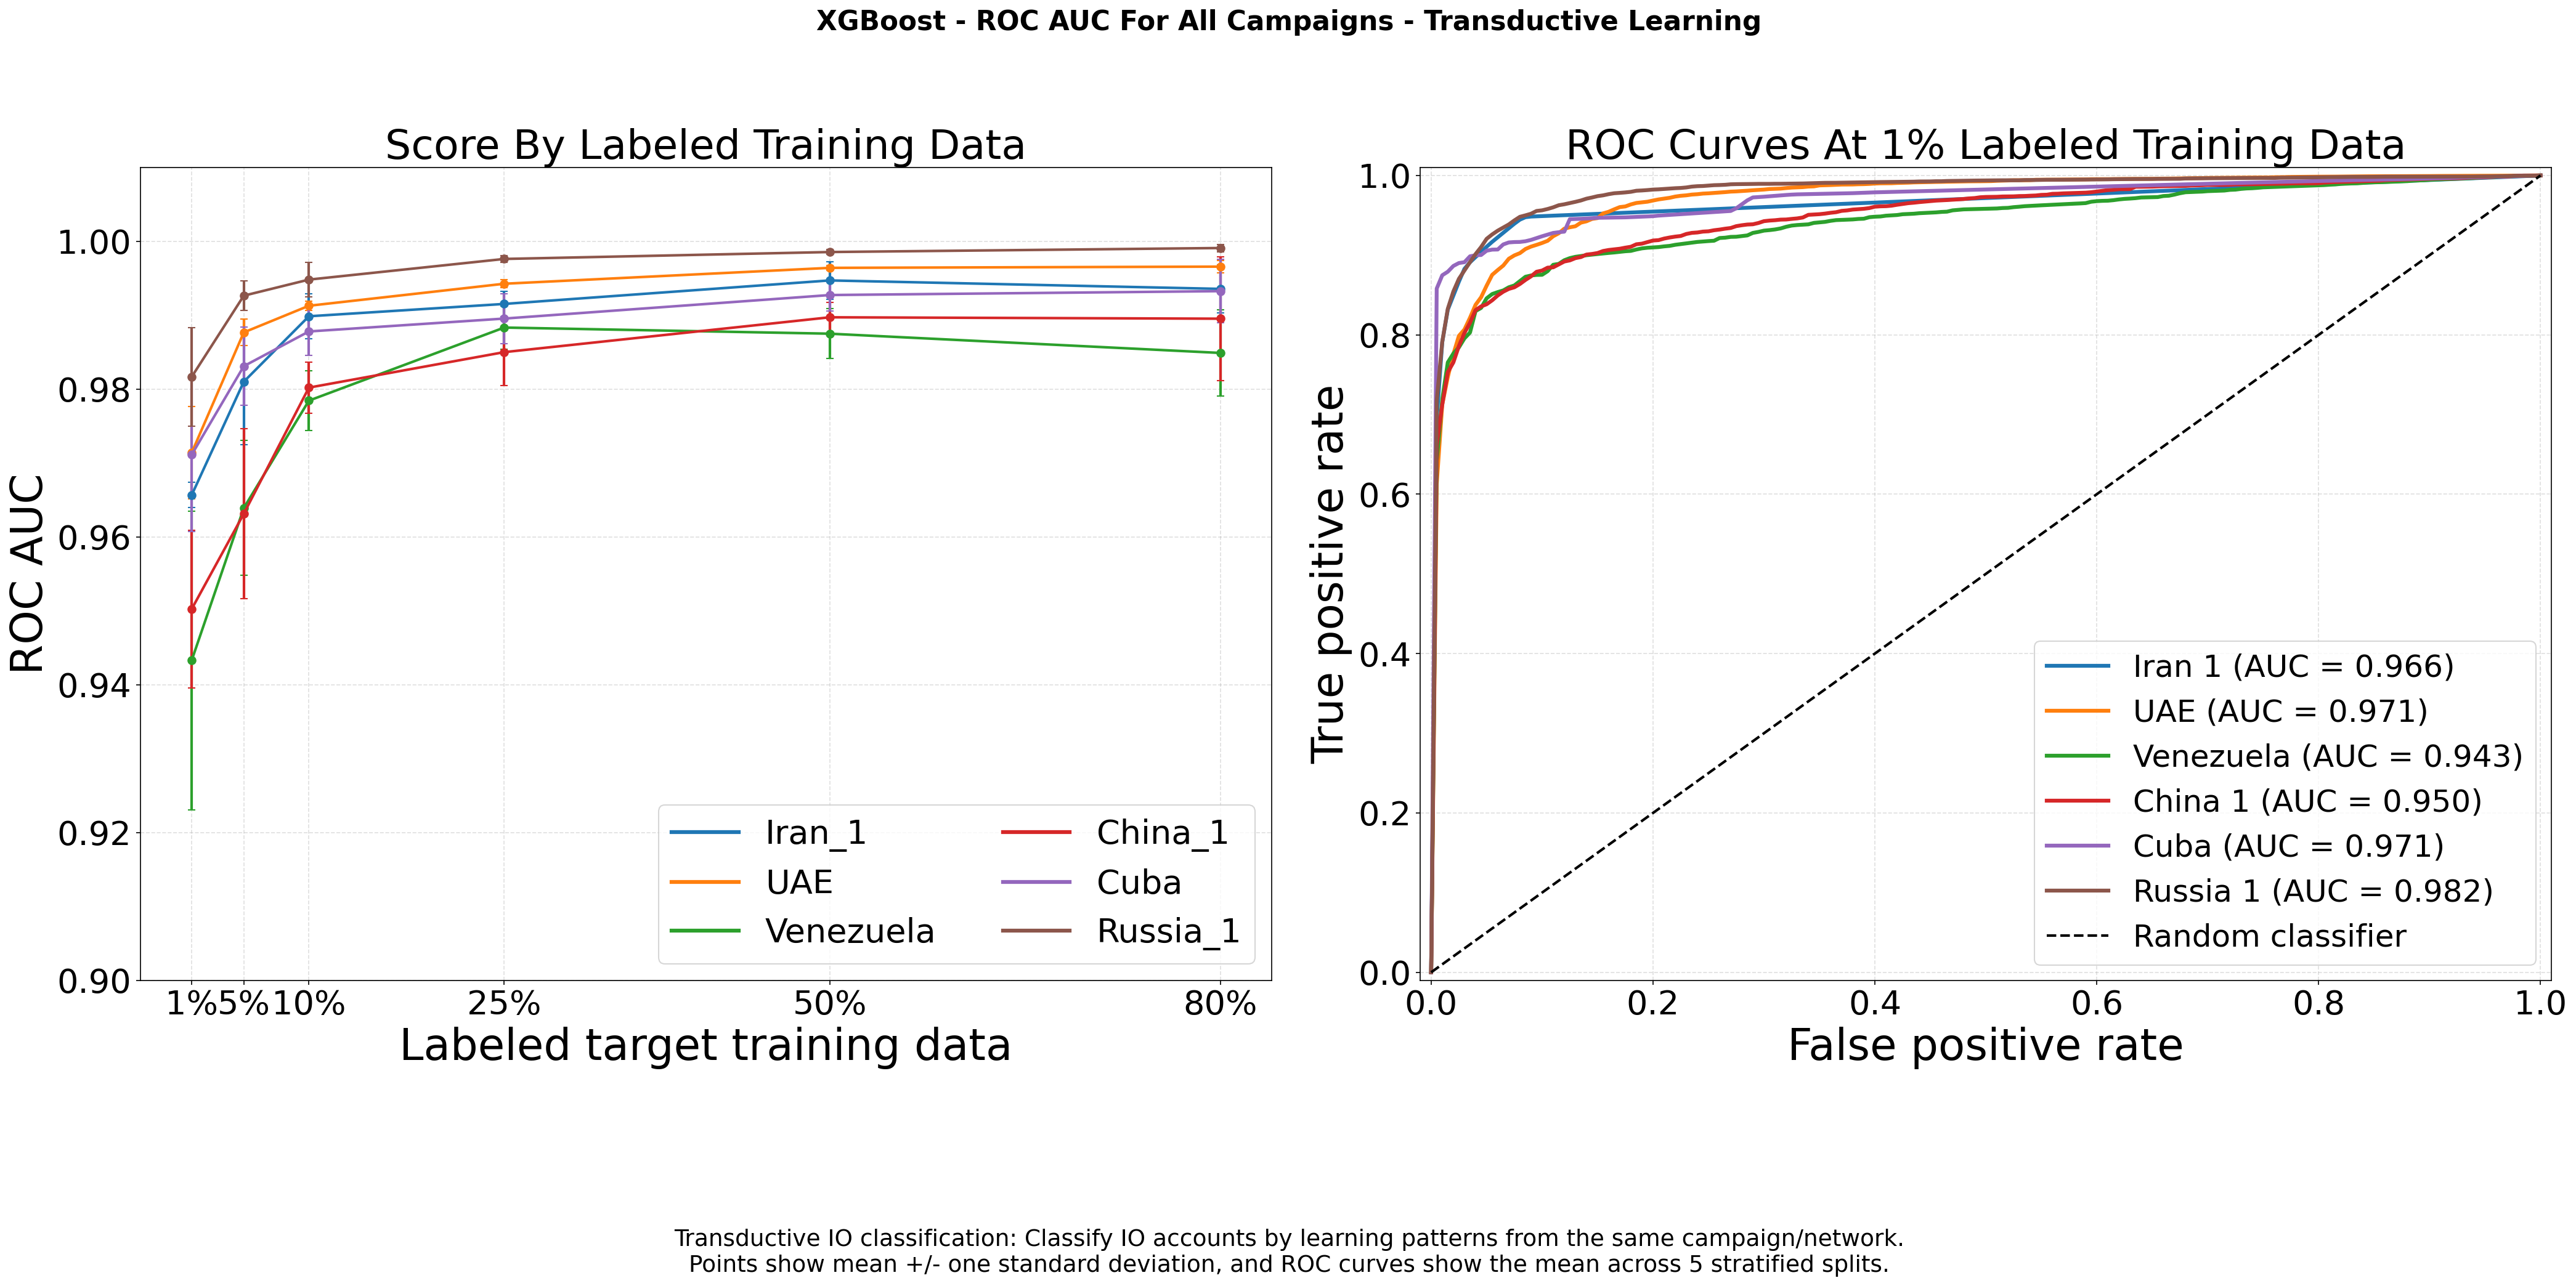

2026-09-06 17:16:05 | Saved plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/top_percentage_100/transductive_within_campaign/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_xgboost_transductive_auc_pr_all_campaigns.png


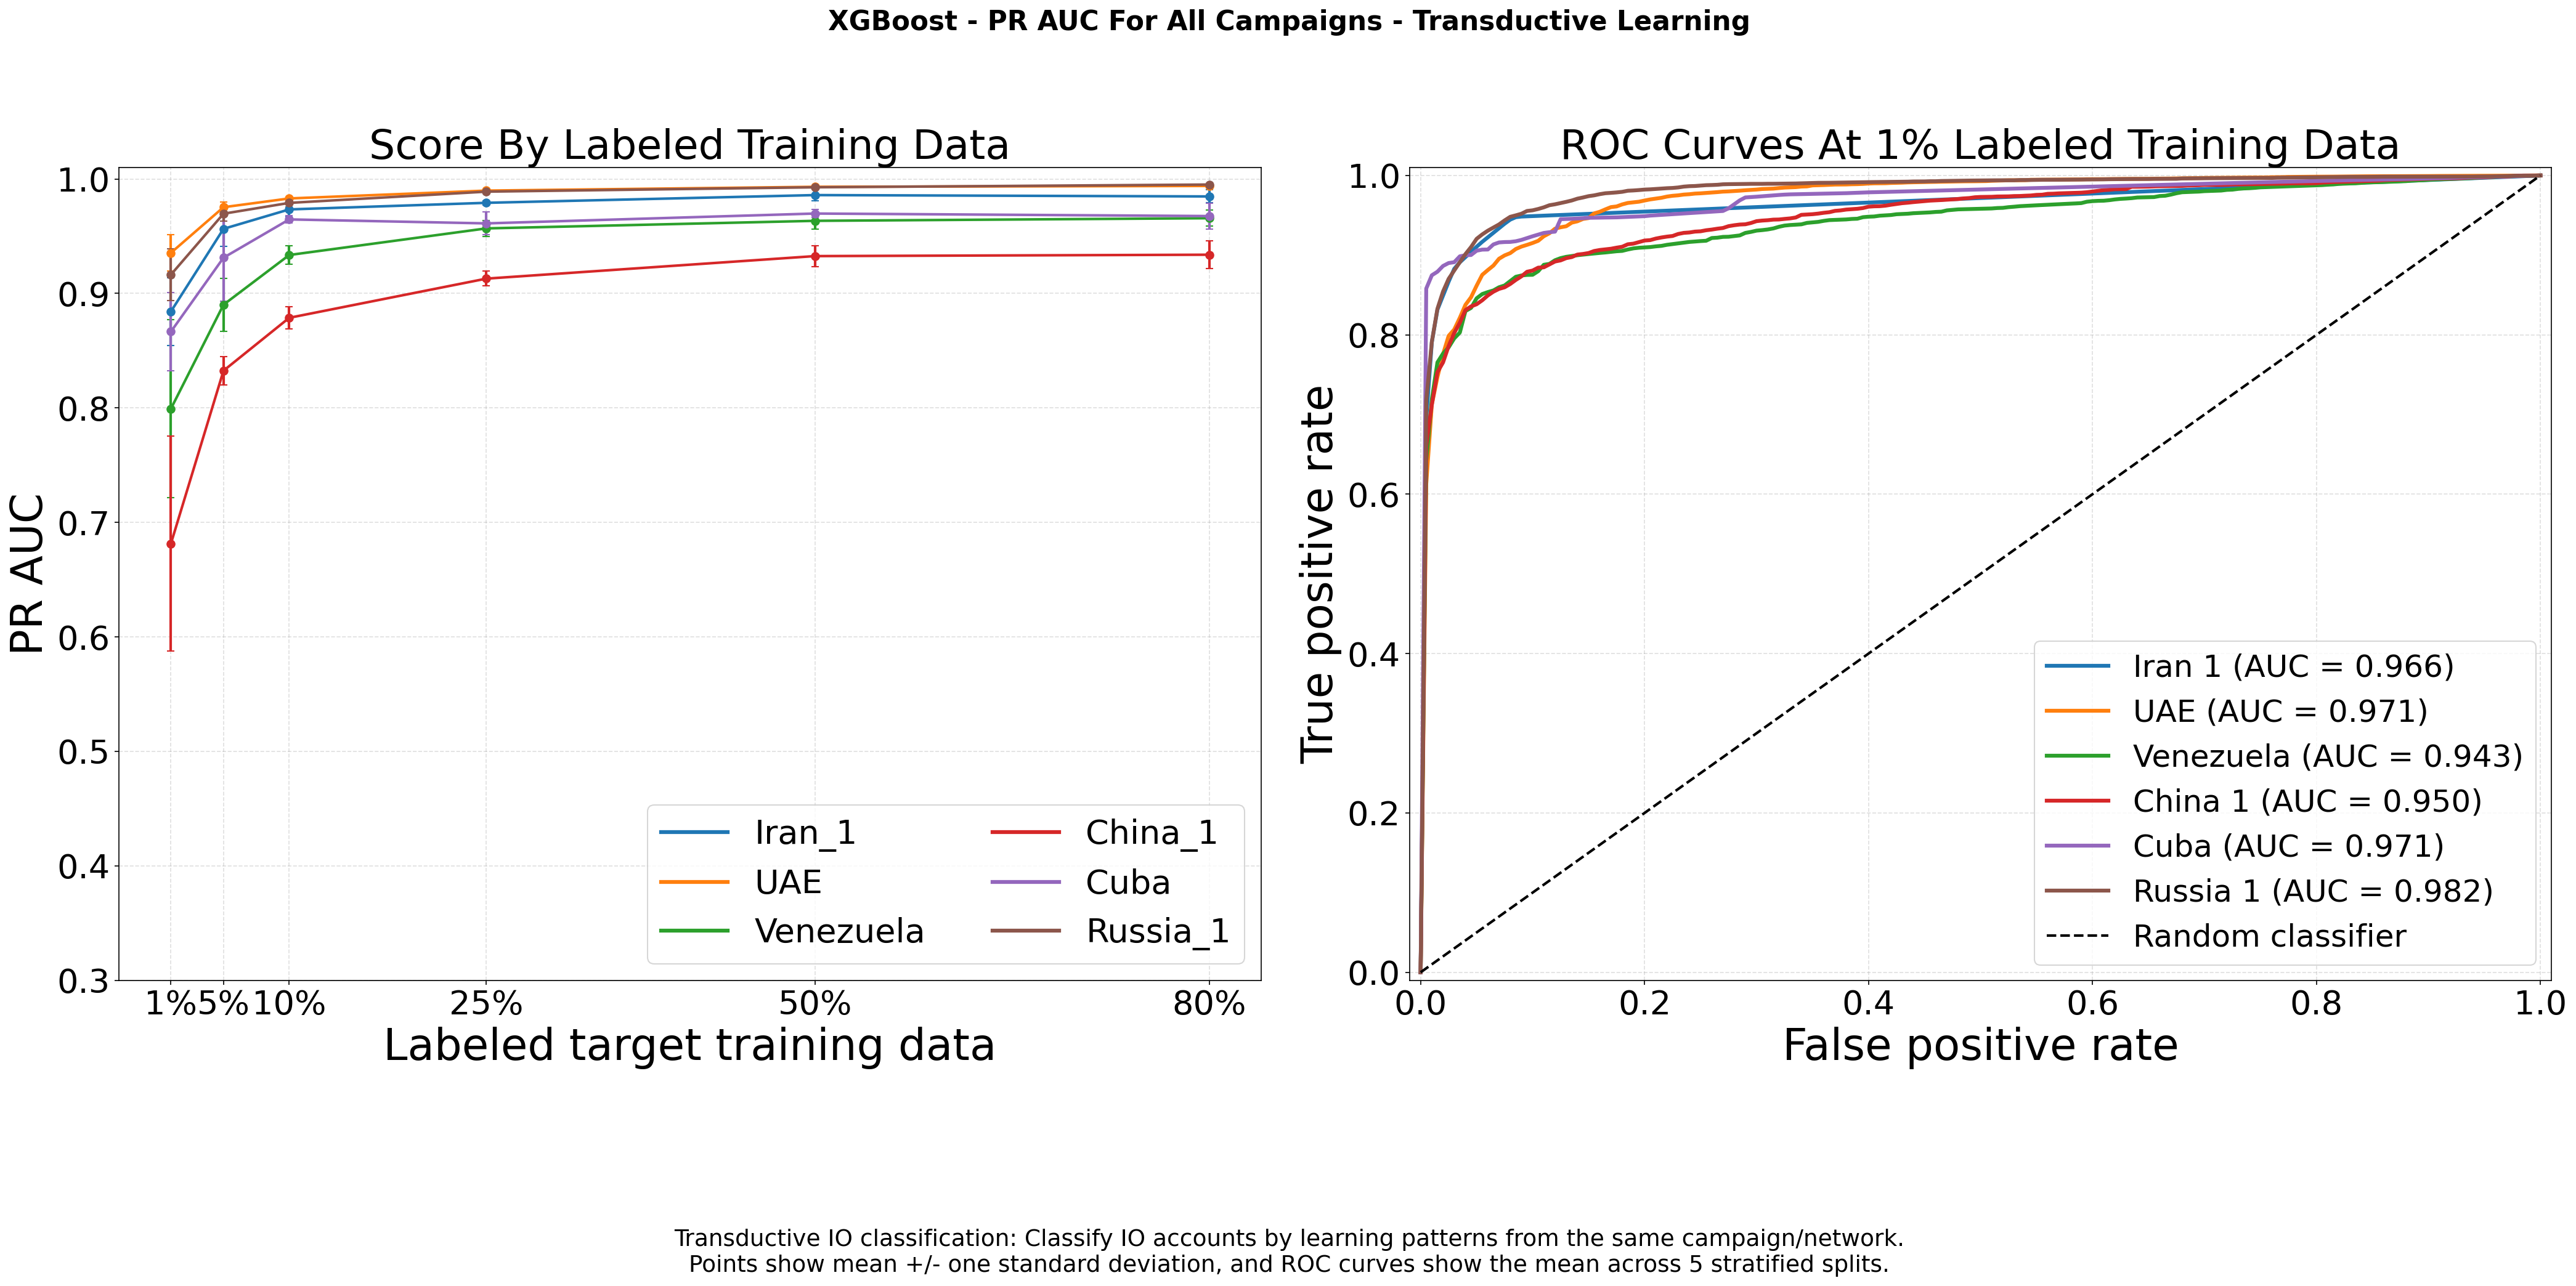

2026-09-06 17:16:12 | Saved plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/top_percentage_100/transductive_within_campaign/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_xgboost_transductive_macro_f1_all_campaigns.png


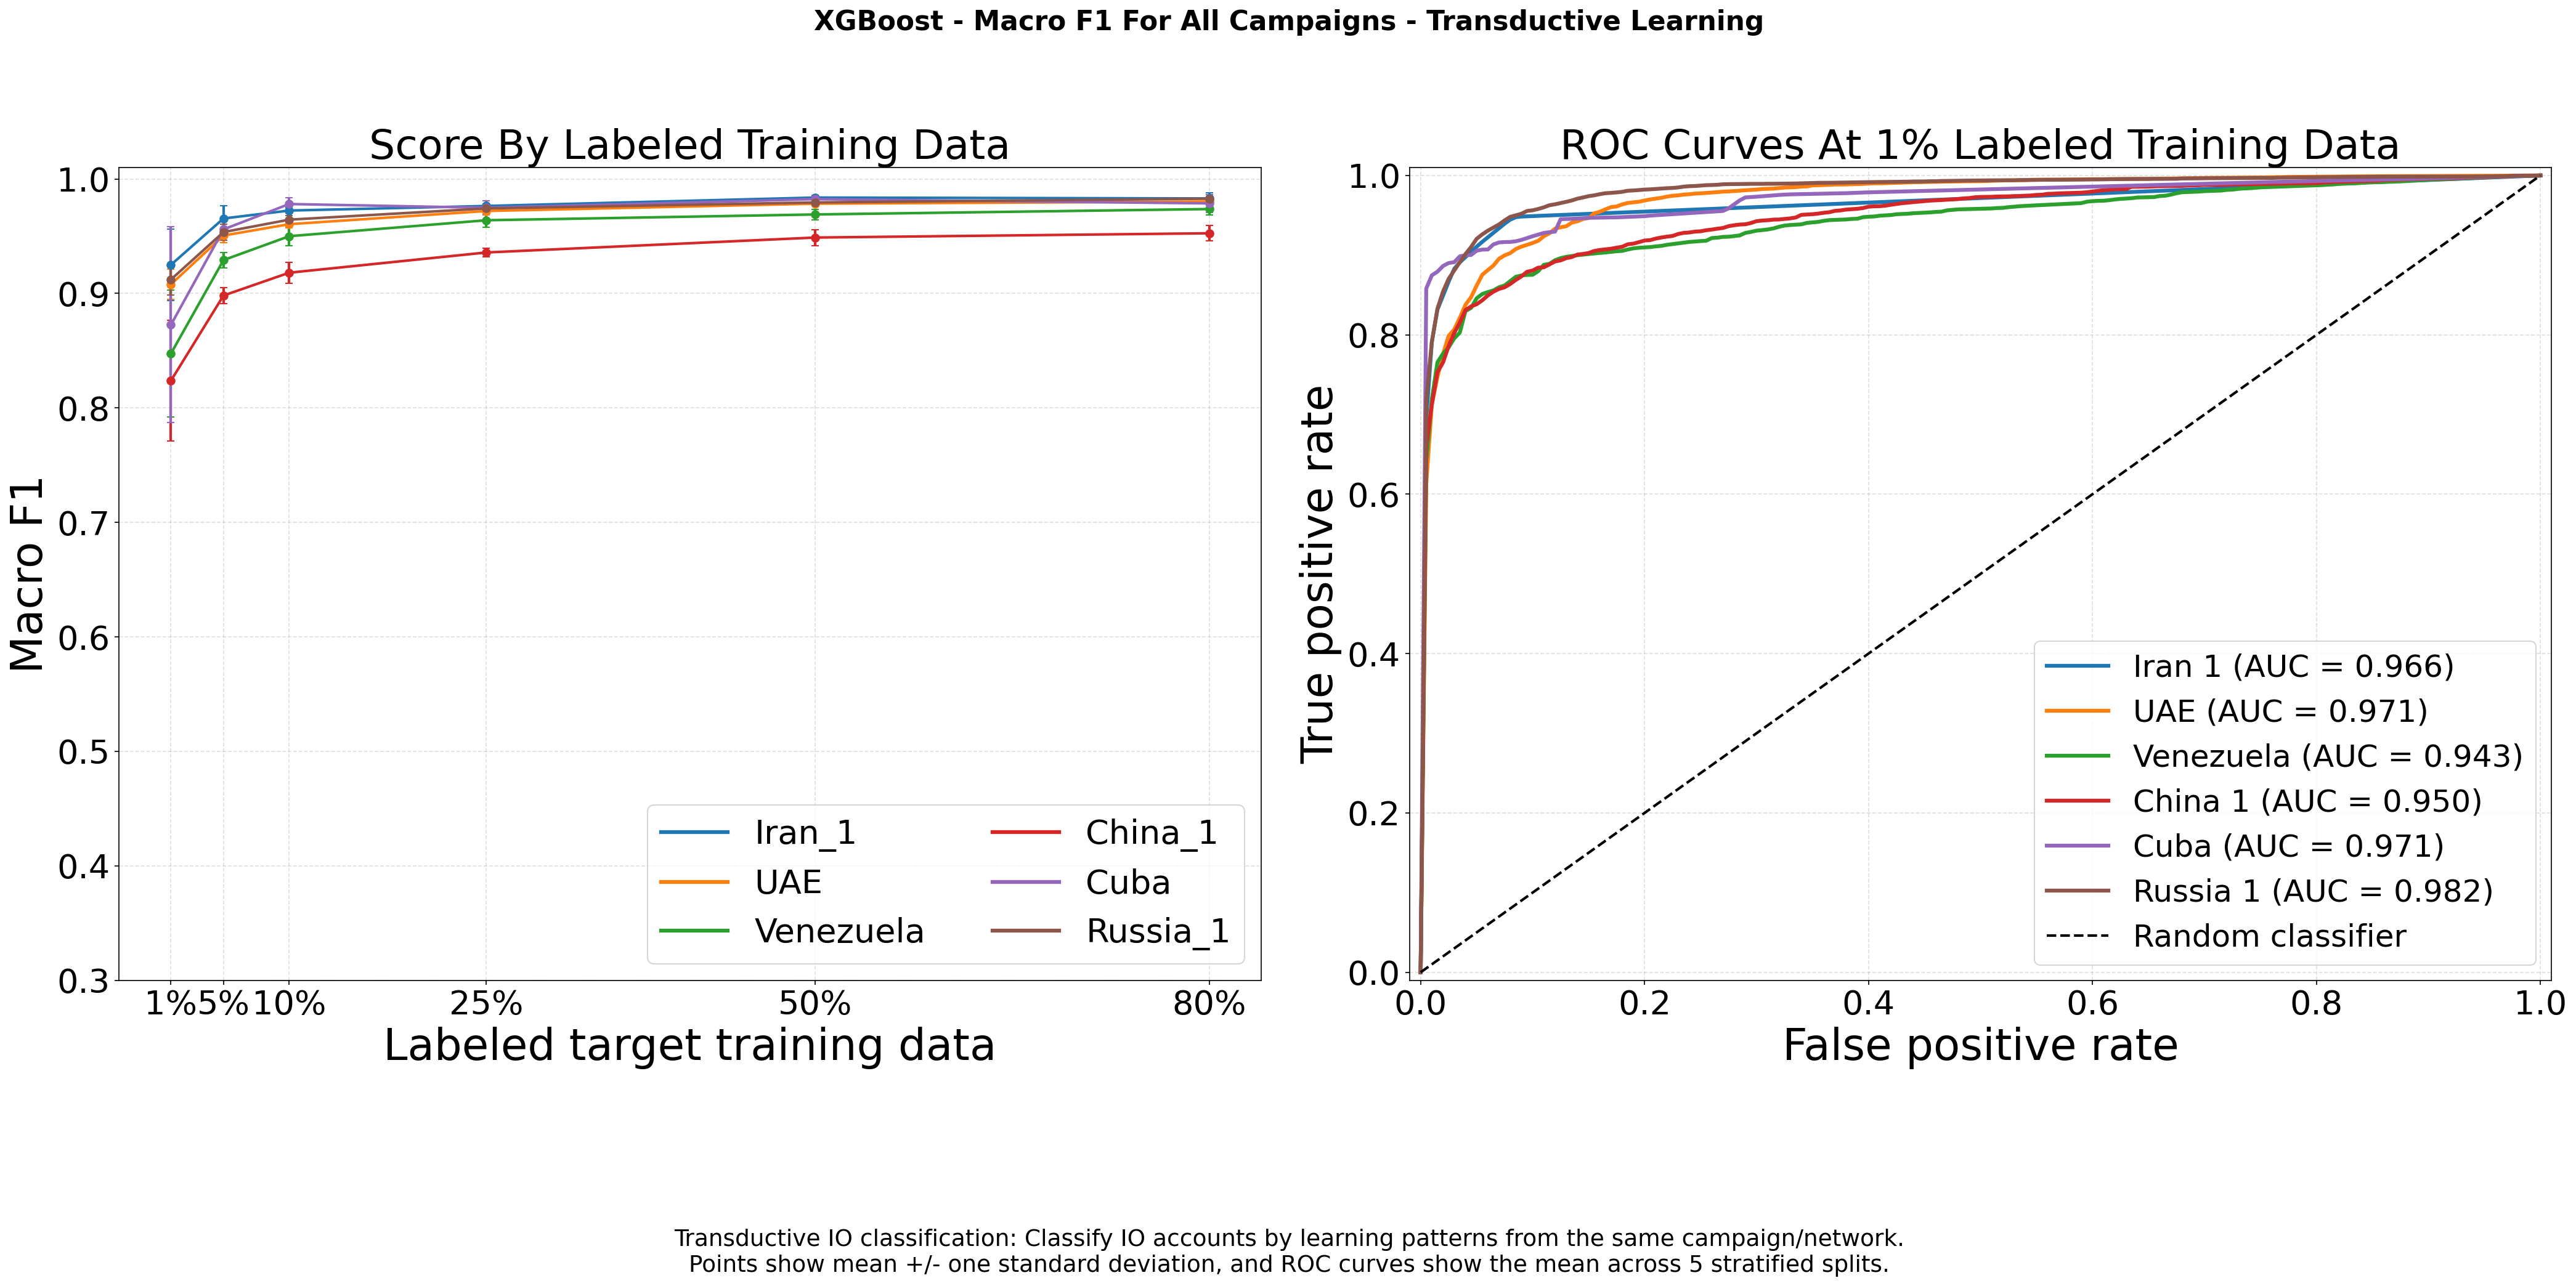

2026-09-06 17:16:18 | Saved plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/top_percentage_100/transductive_within_campaign/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_xgboost_transductive_optimized_f1_all_campaigns.png


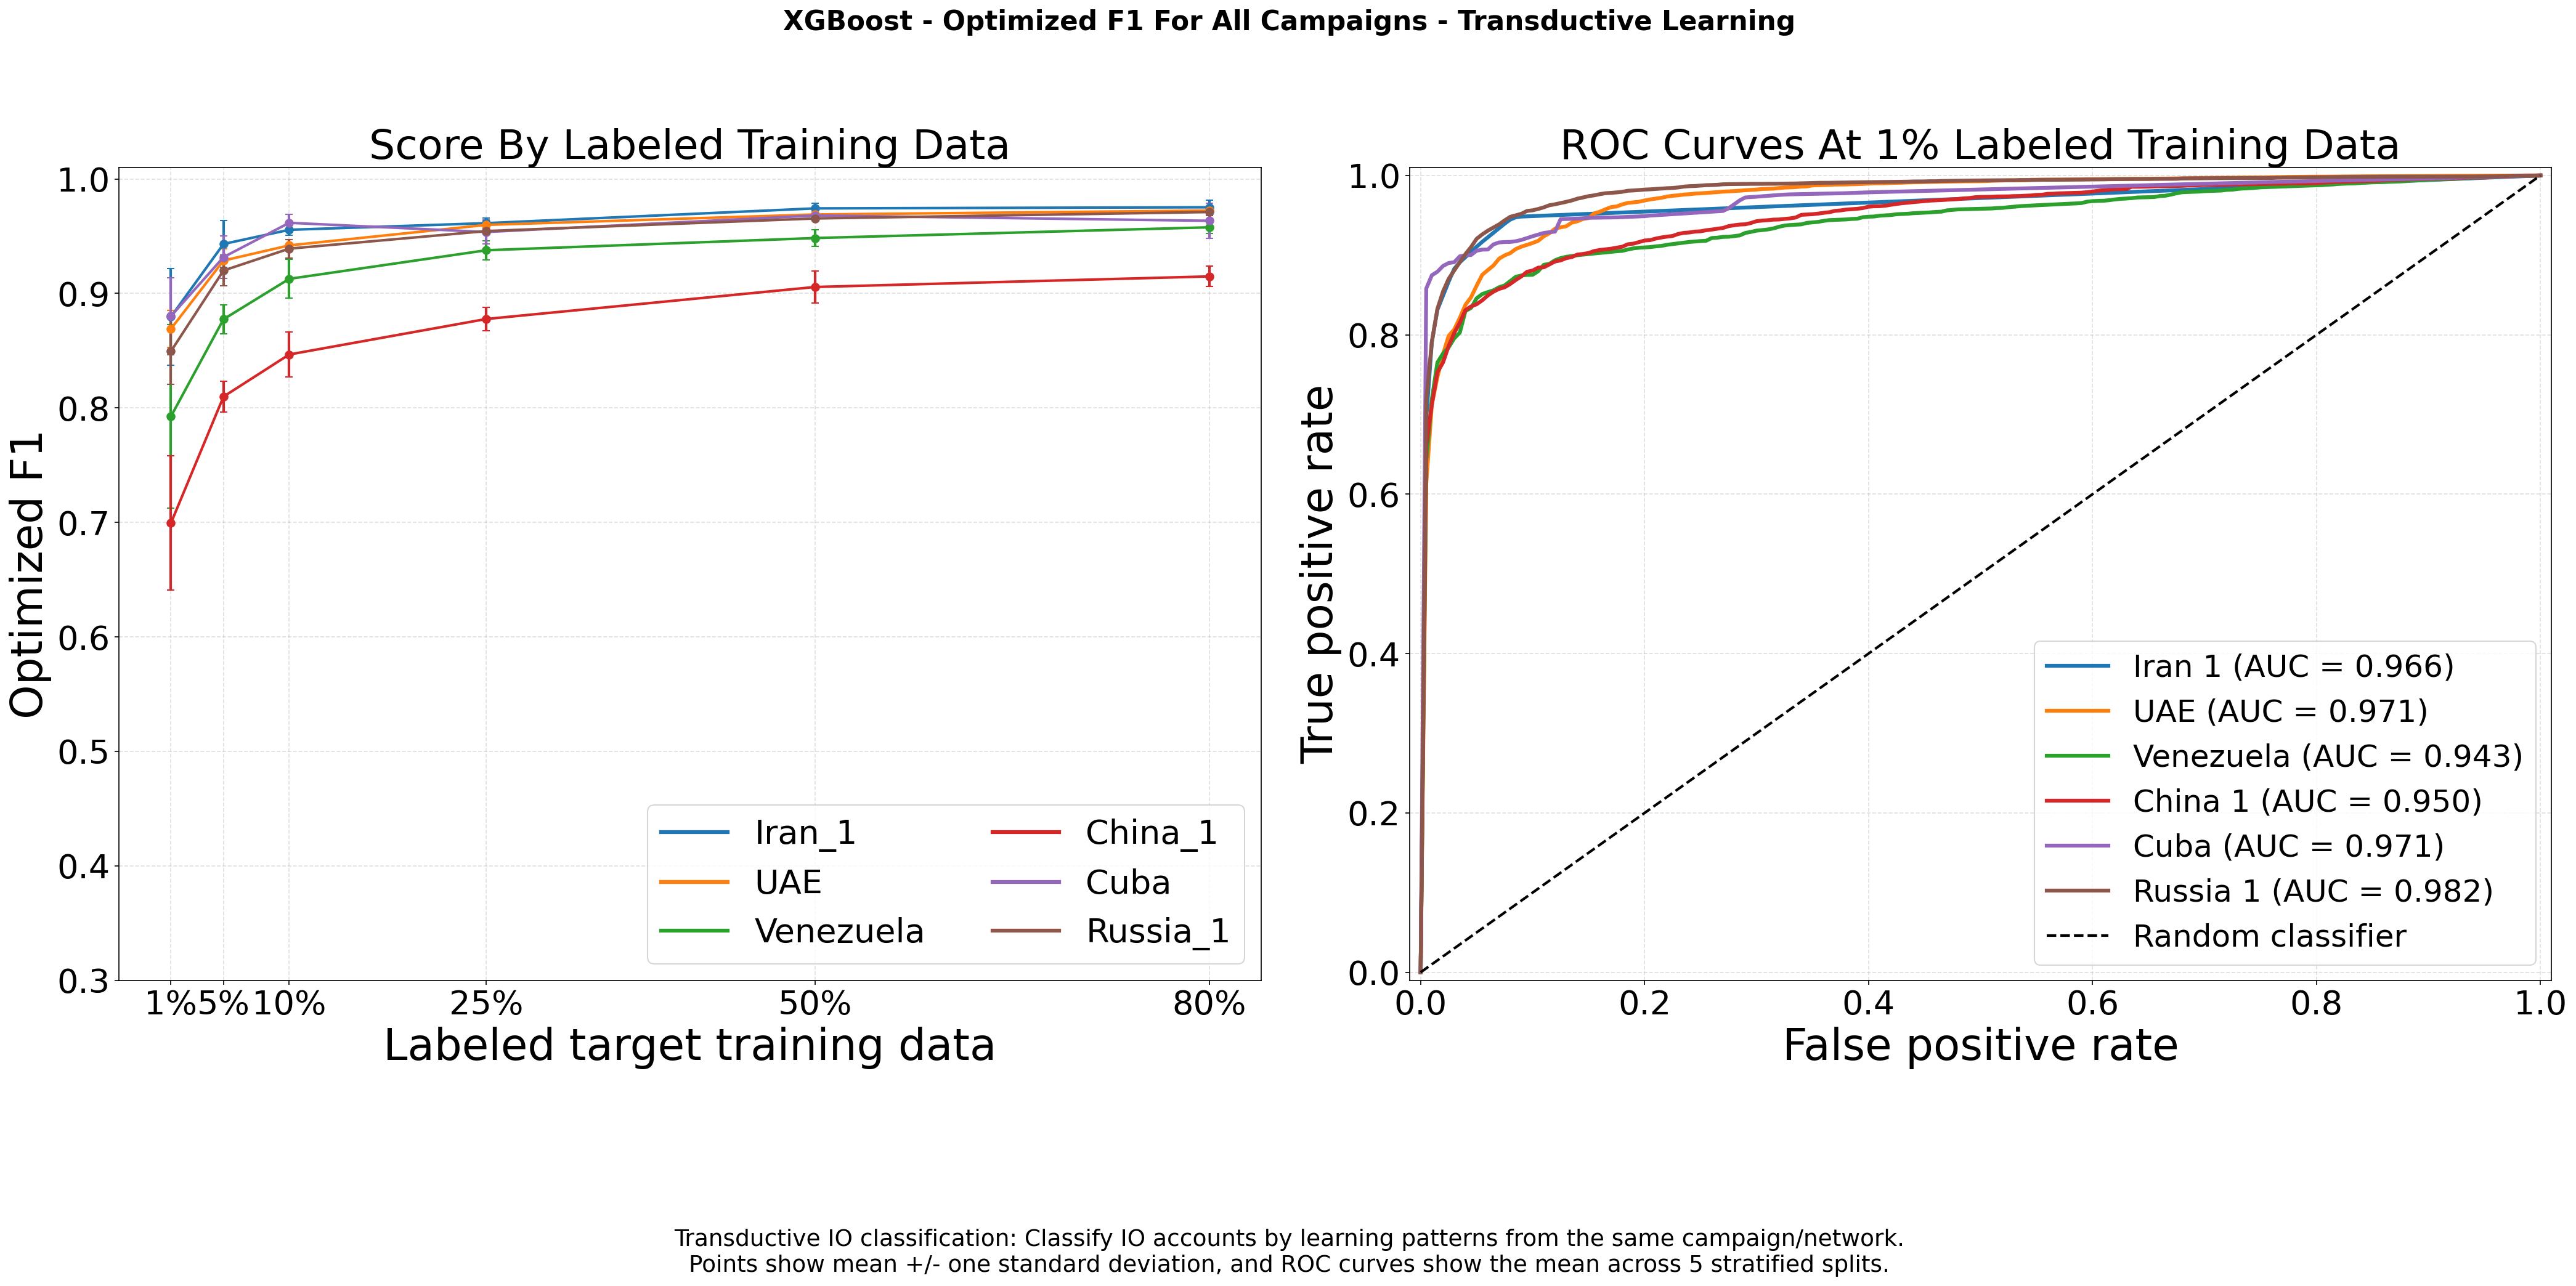

2026-09-06 17:16:25 | Saved plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/top_percentage_100/transductive_within_campaign/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_random_forest_transductive_auc_roc_all_campaigns.png


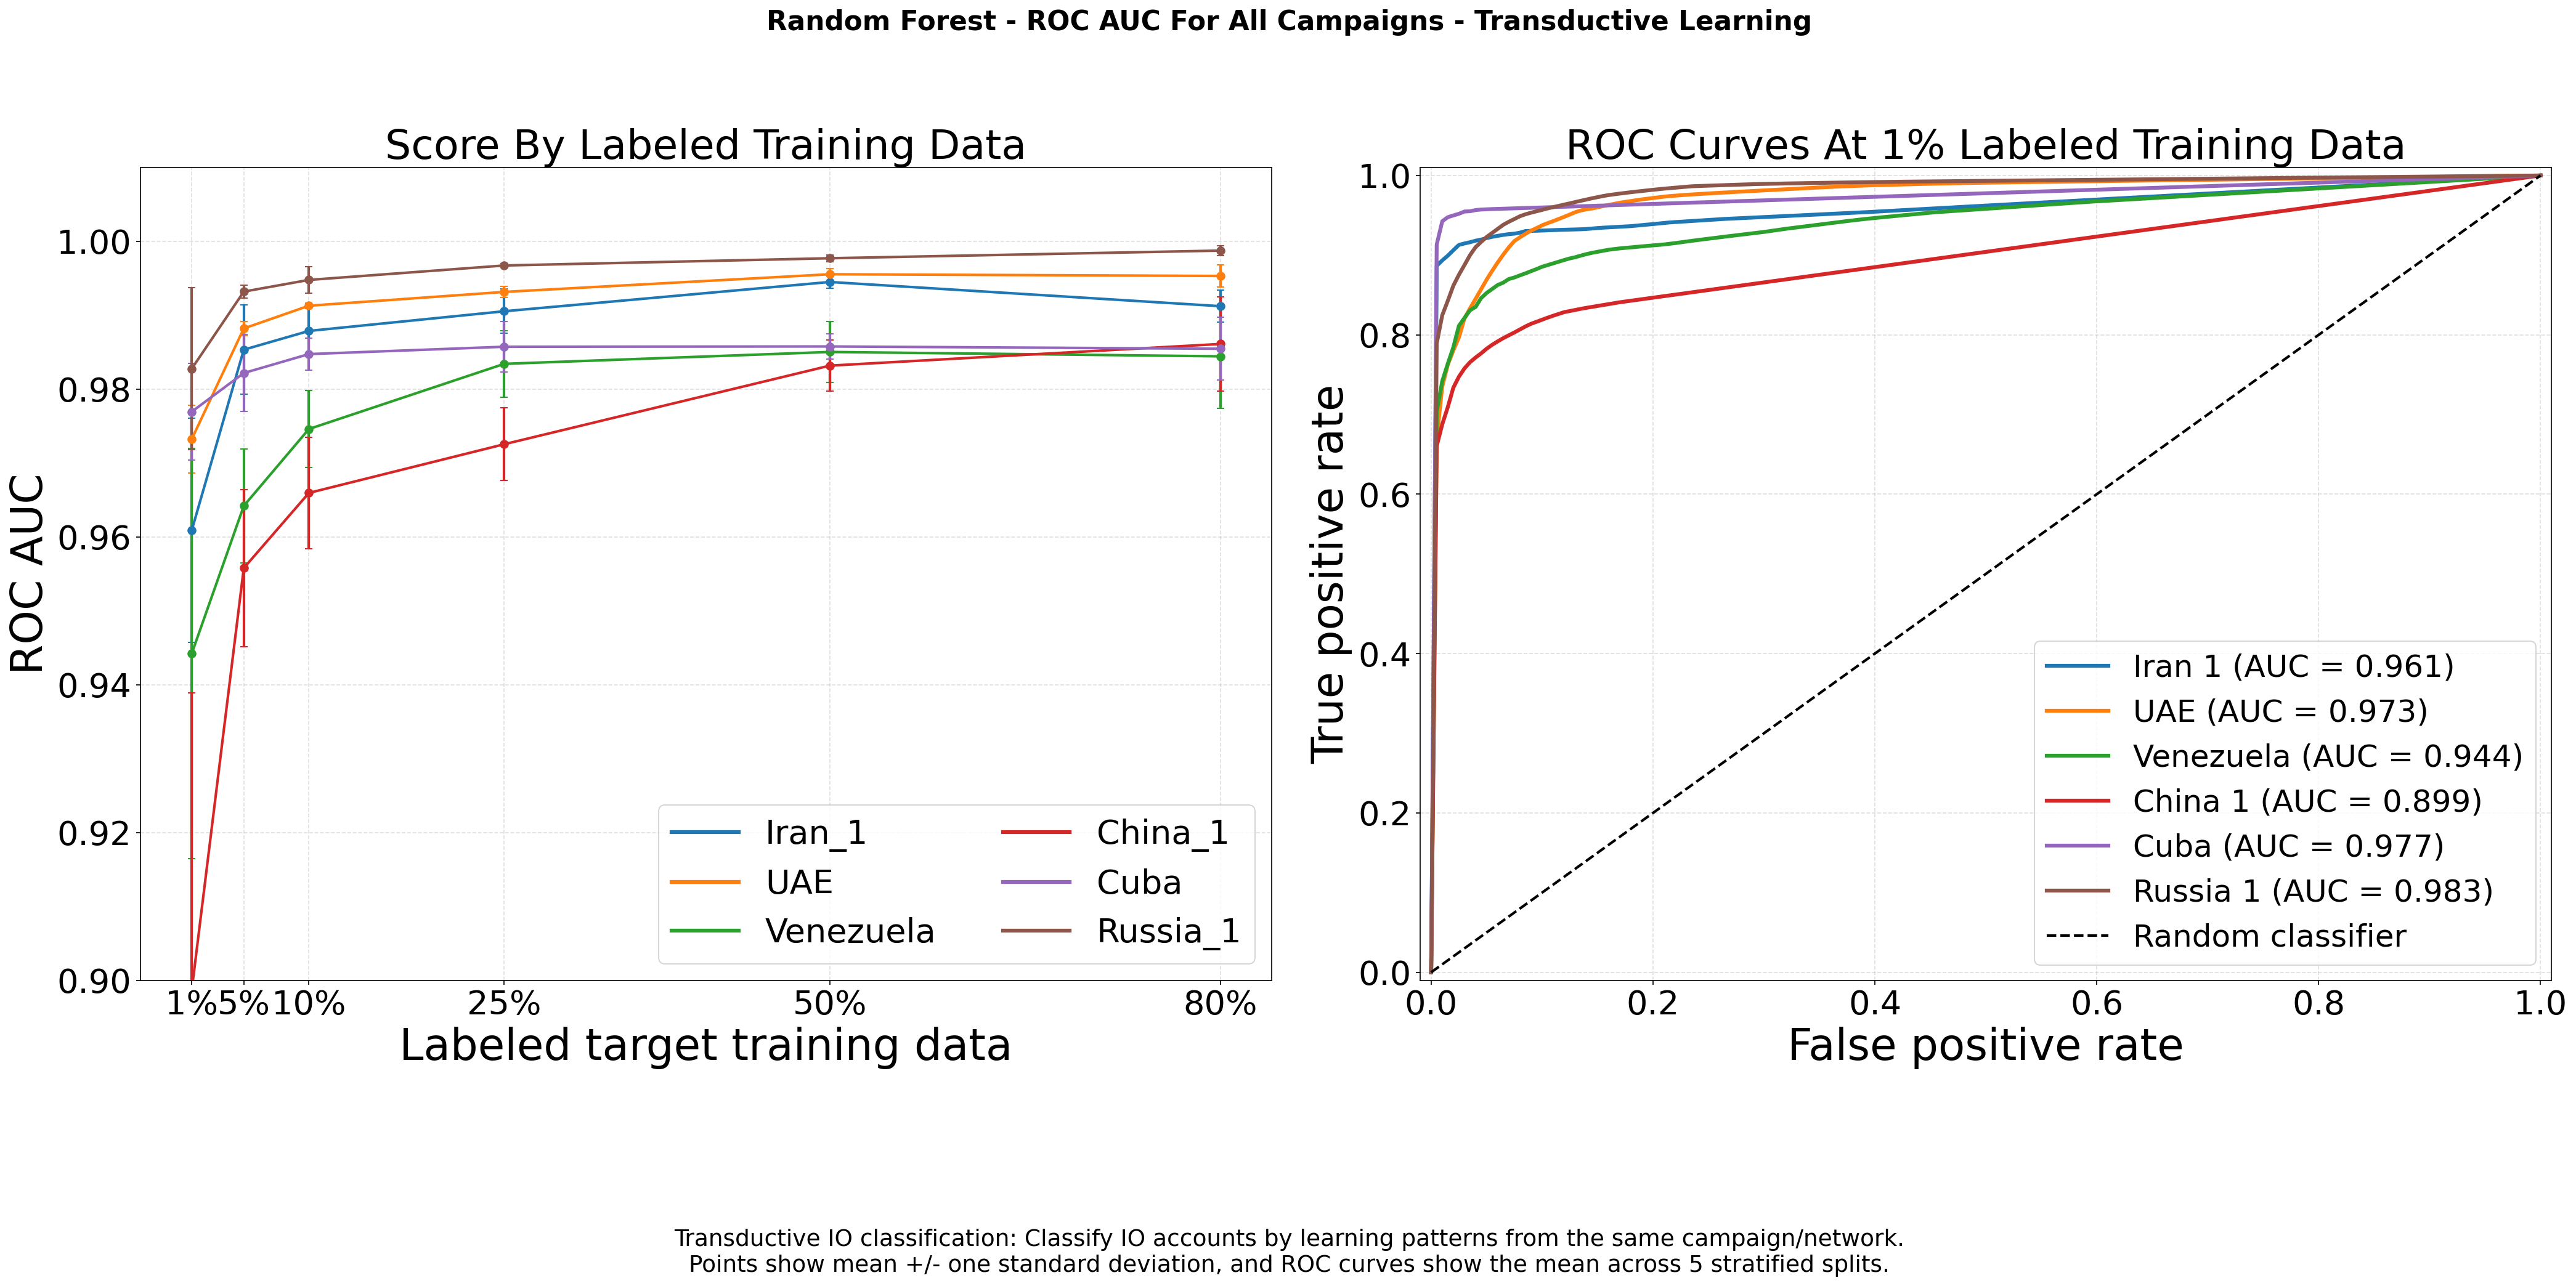

2026-09-06 17:16:31 | Saved plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/top_percentage_100/transductive_within_campaign/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_random_forest_transductive_auc_pr_all_campaigns.png


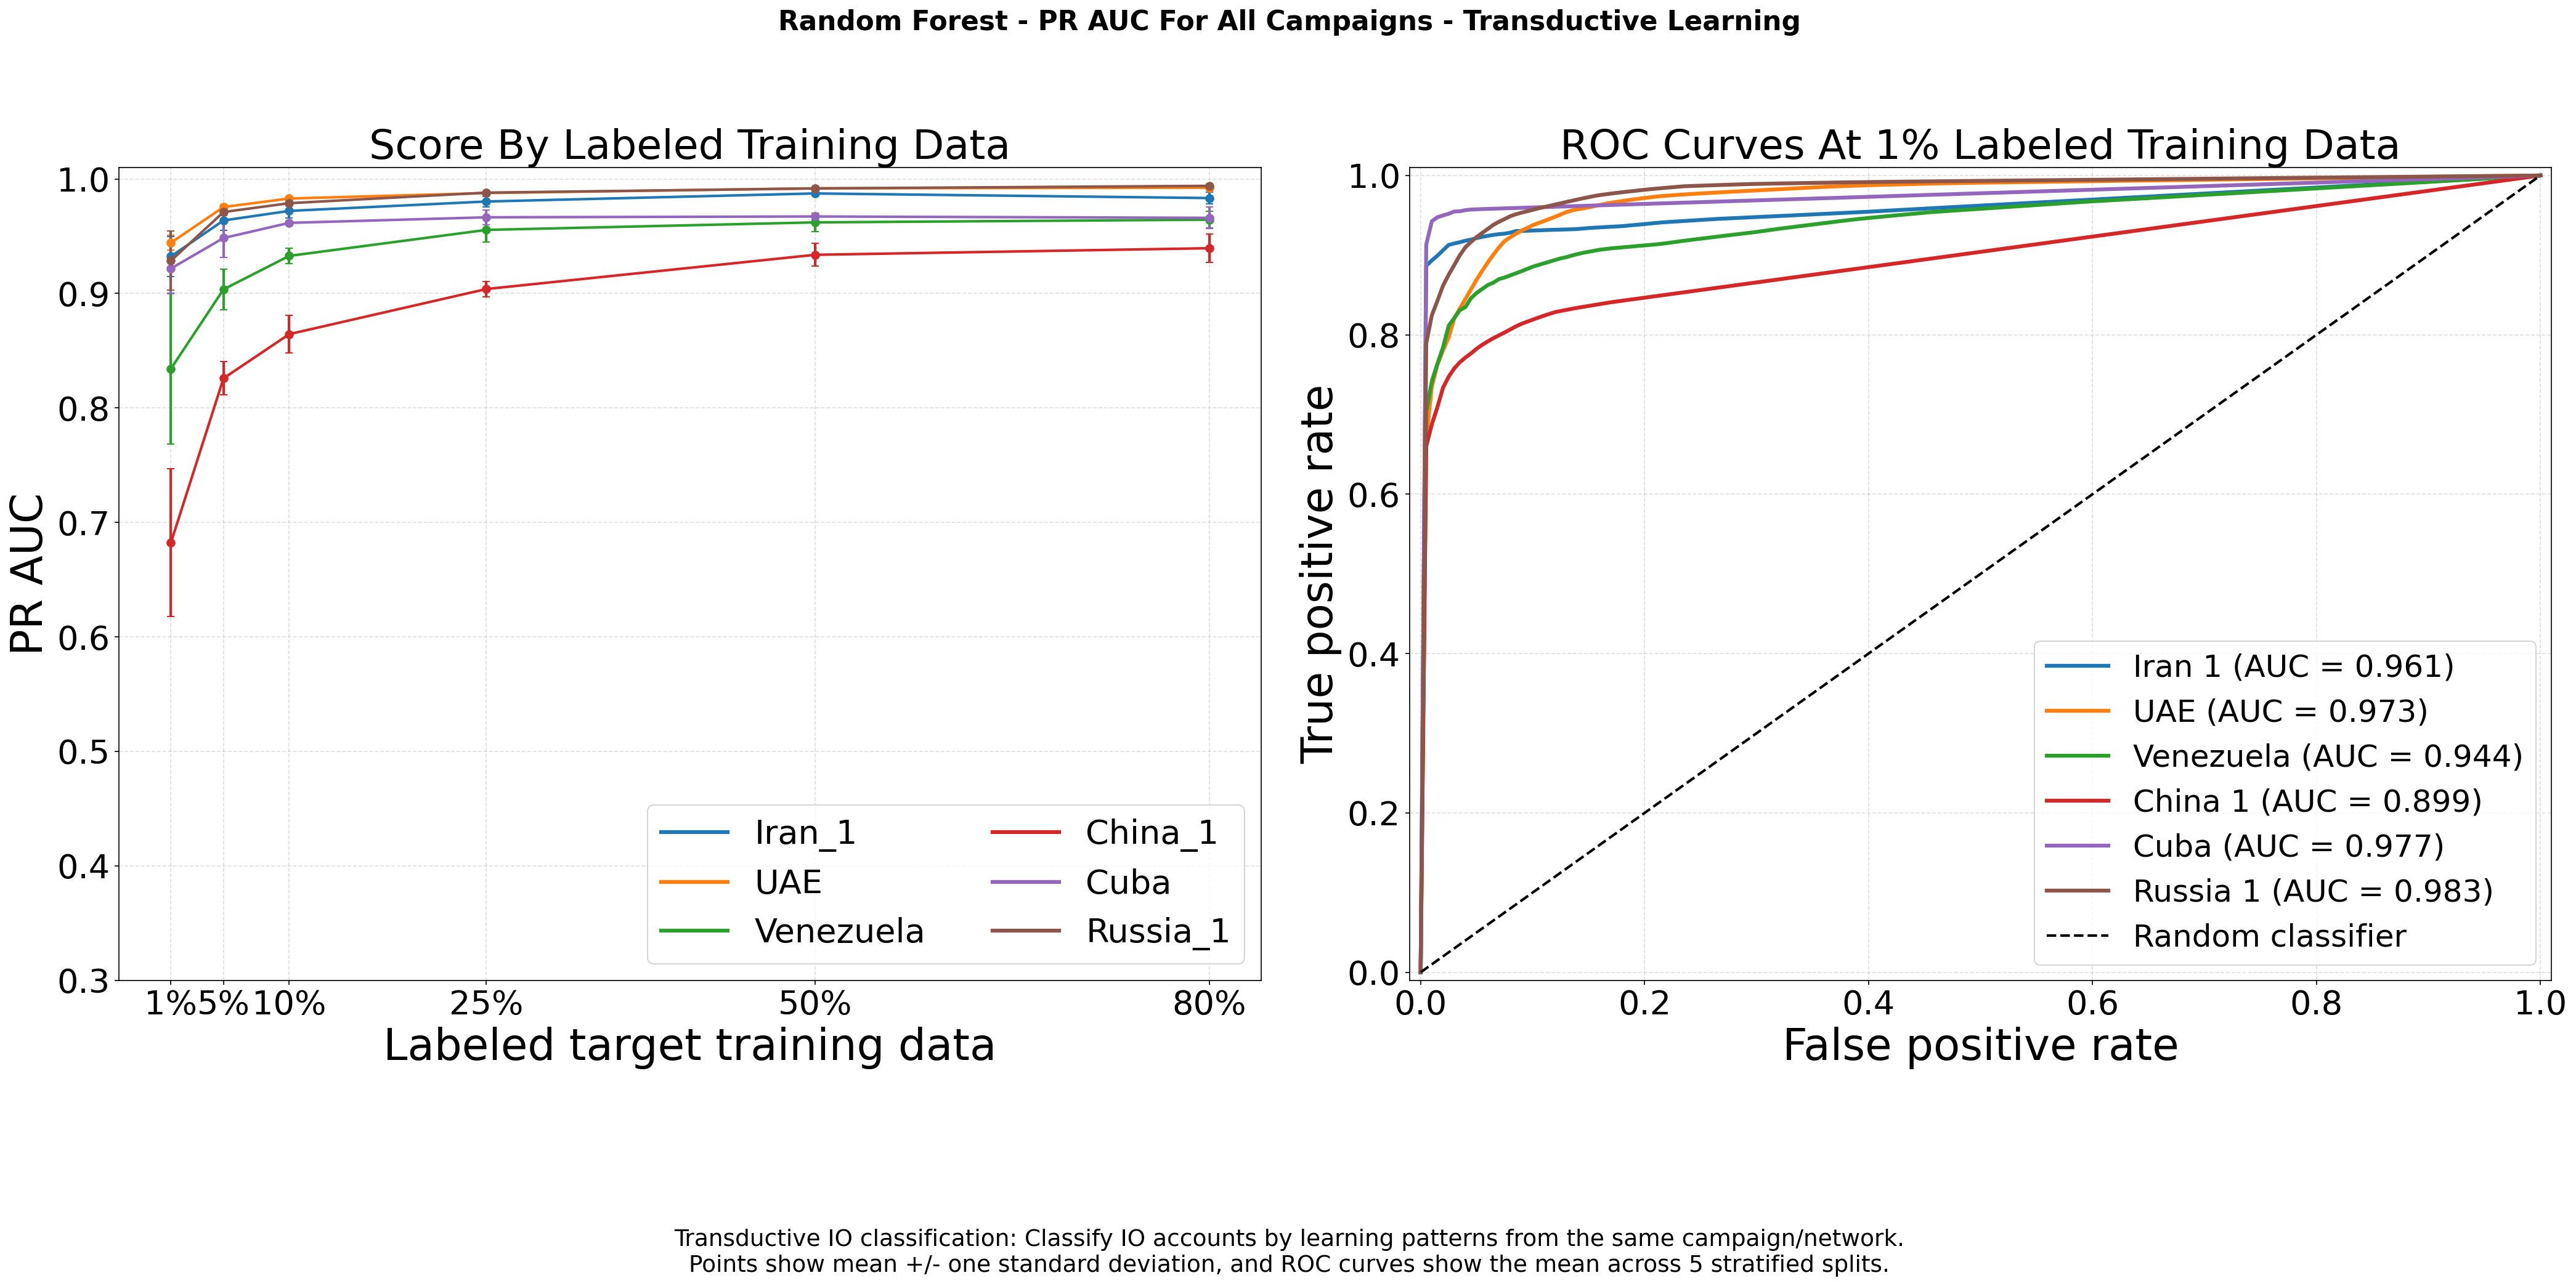

2026-09-06 17:16:38 | Saved plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/top_percentage_100/transductive_within_campaign/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_random_forest_transductive_macro_f1_all_campaigns.png


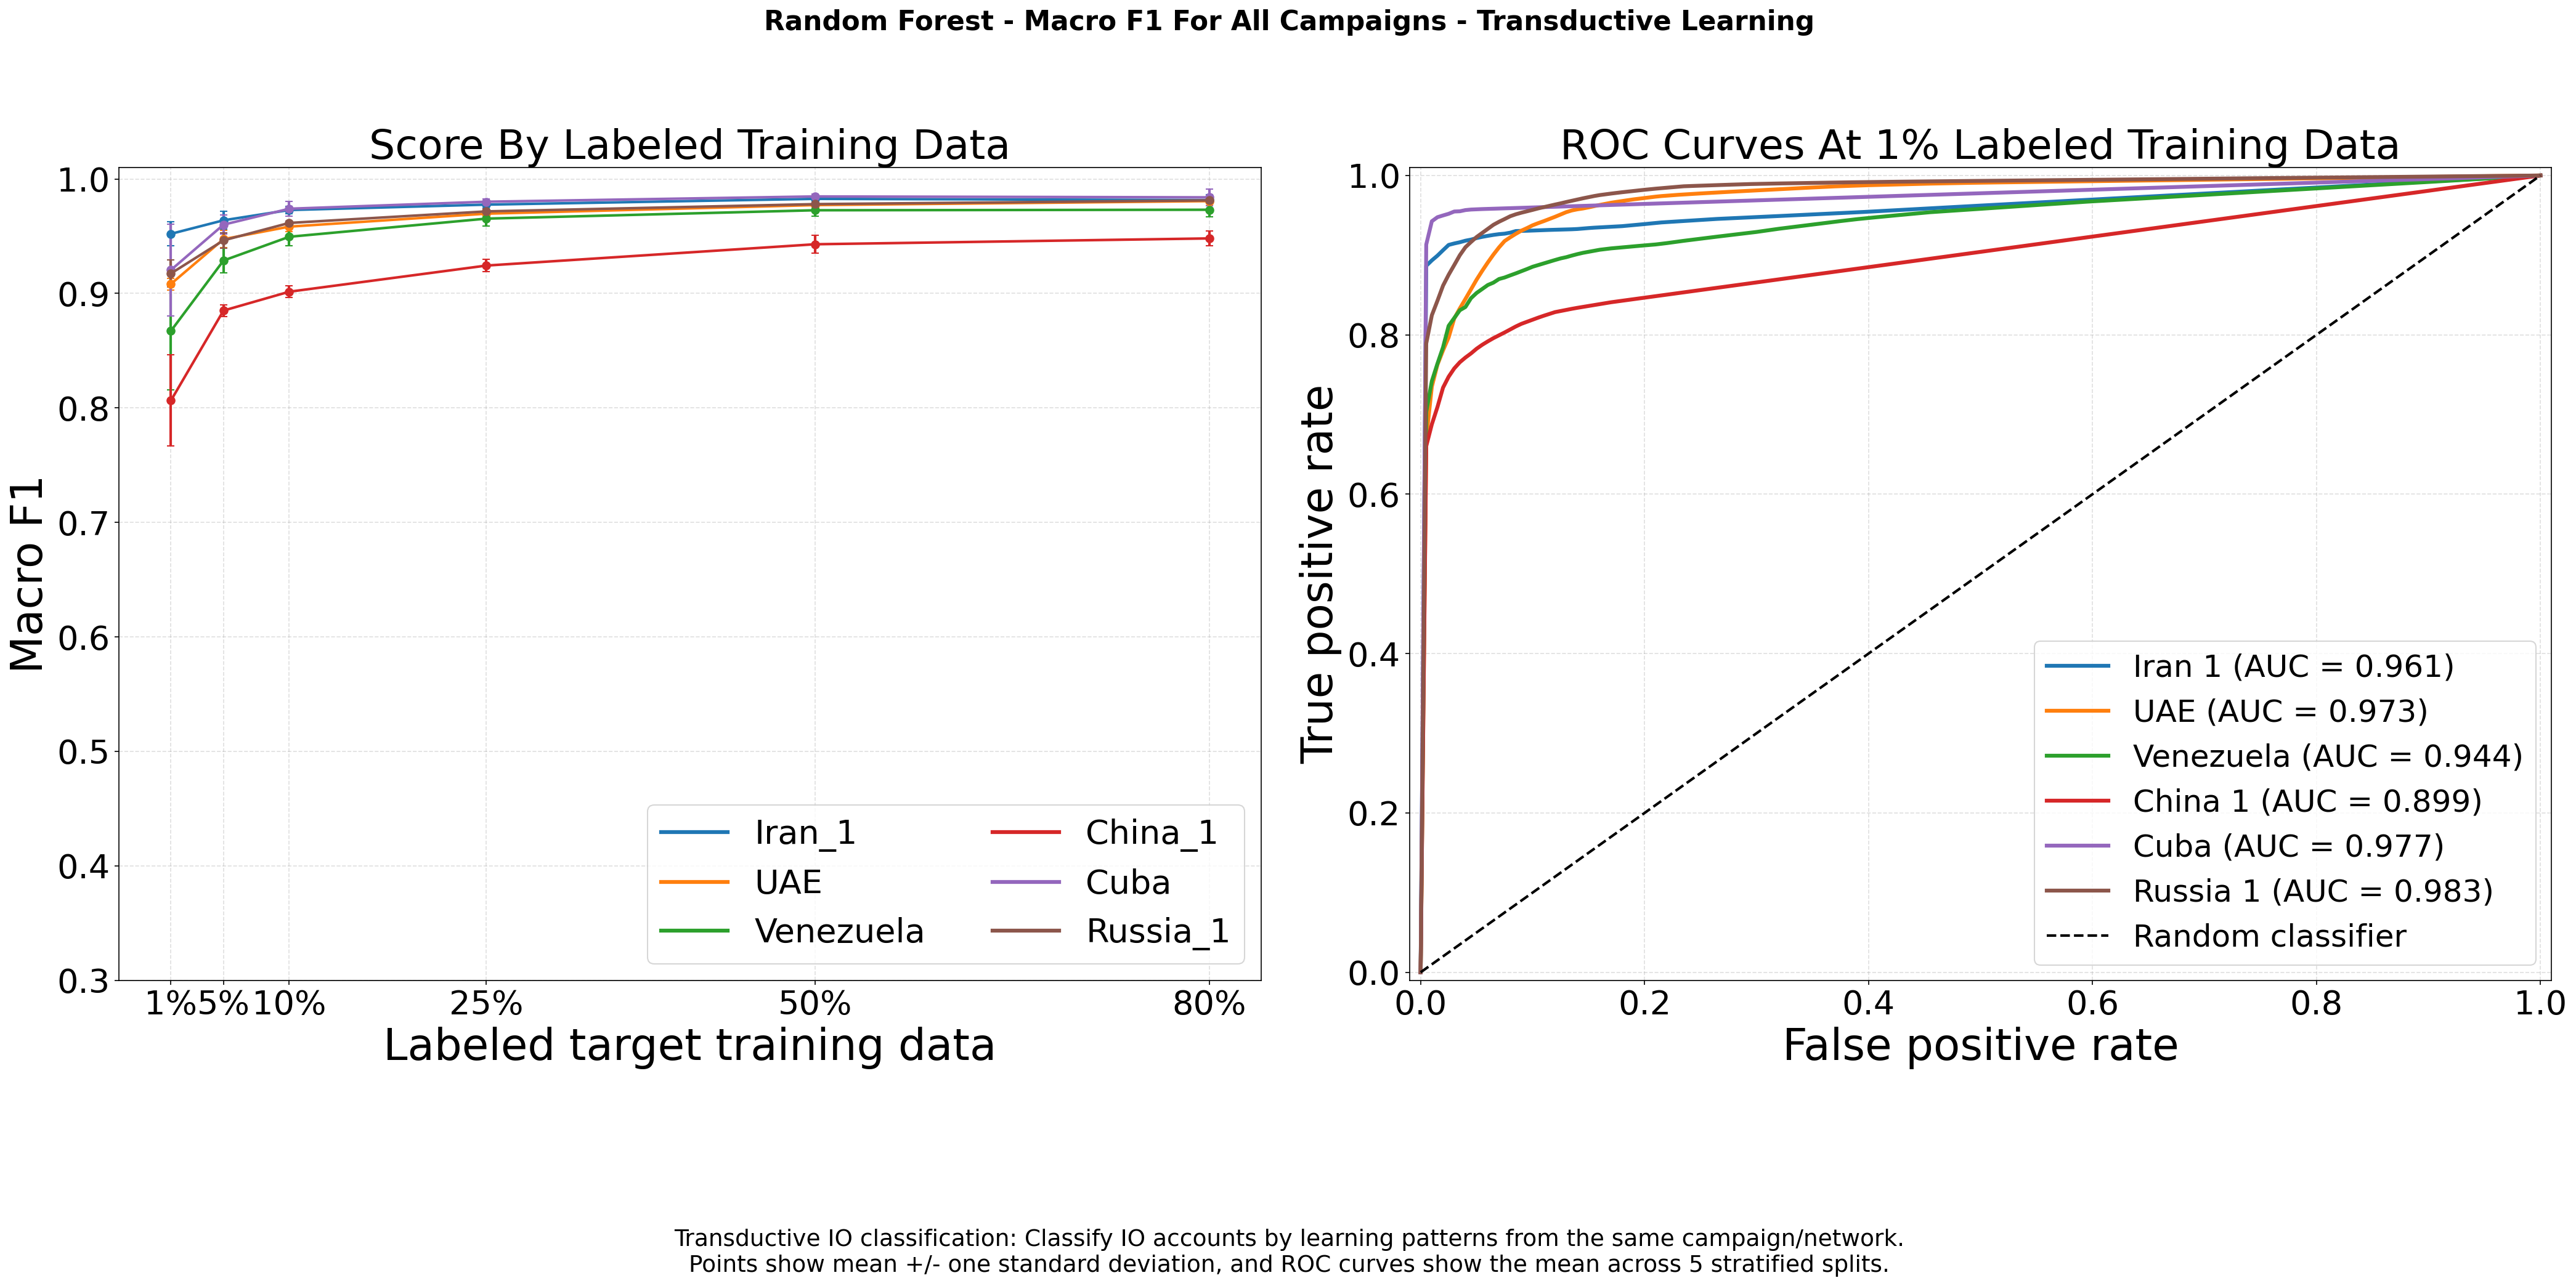

2026-09-06 17:16:44 | Saved plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/top_percentage_100/transductive_within_campaign/experiment_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_random_forest_transductive_optimized_f1_all_campaigns.png


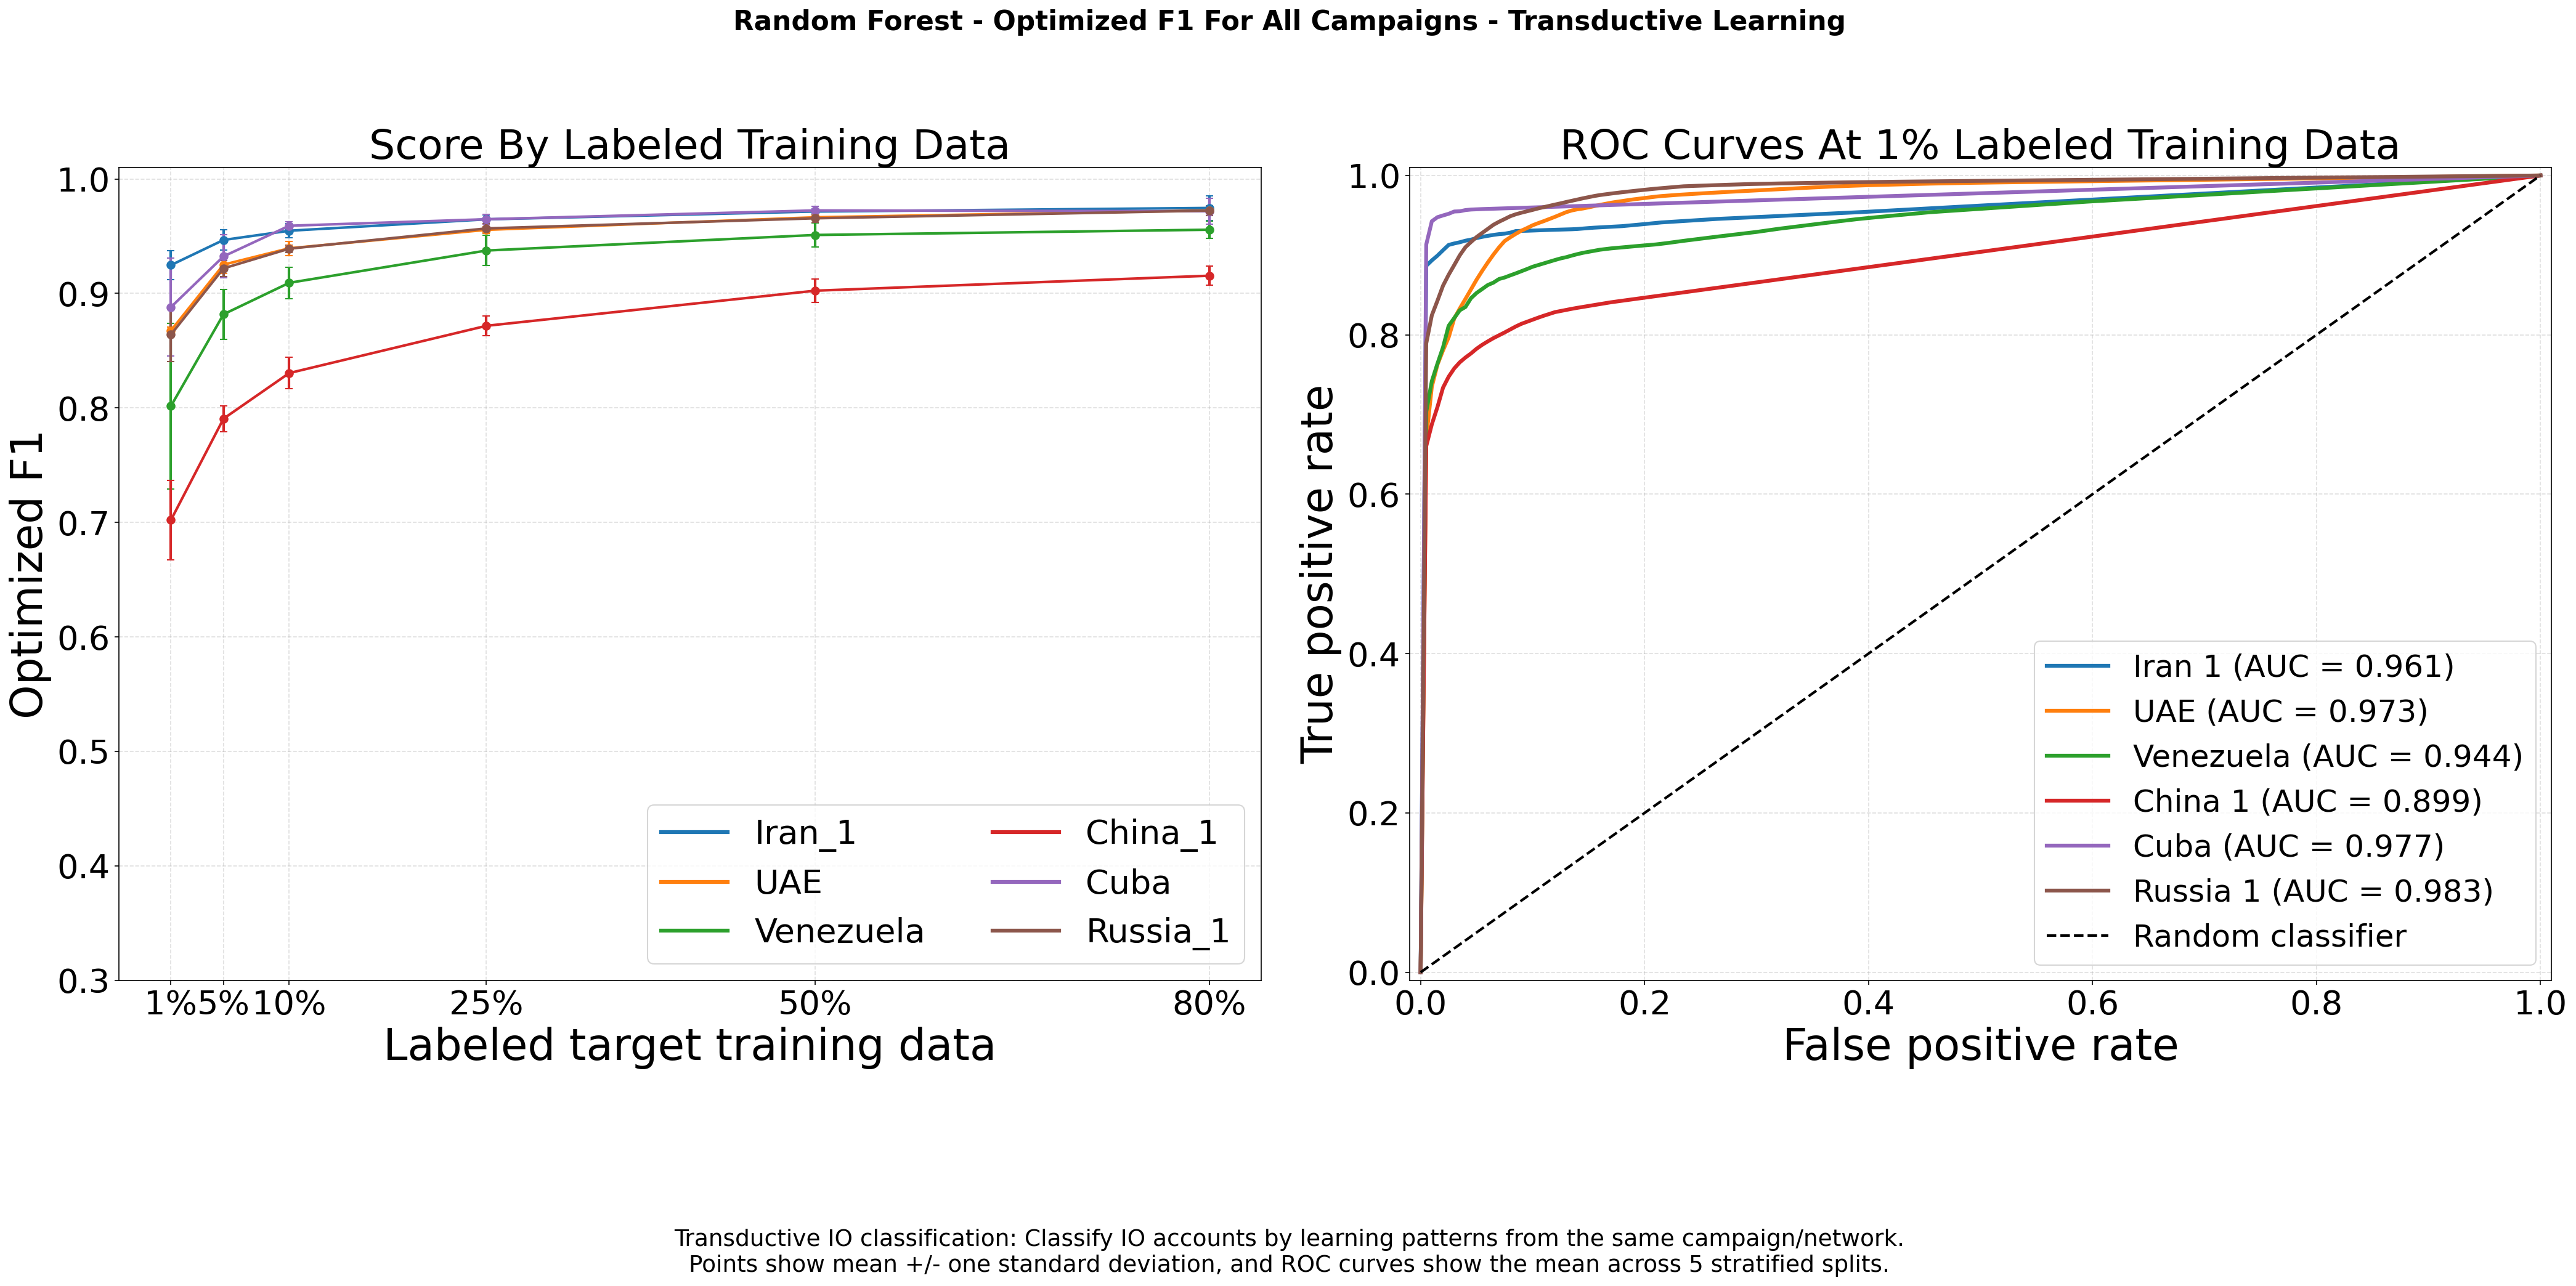

2026-09-06 17:16:45 | Within-campaign evaluation completed.


In [36]:
if not results_df.empty:
    for model_name in MODELS:
        for metric in ("auc_roc", "auc_pr", "macro_f1", "optimized_f1"):
            plot_campaign_performance(
                results_df, metric, "transductive", model_name,
                output_dir=transductive_output_path,
            )
write_report("Within-campaign evaluation completed.")

## IOHunter Experiment

60% Train, 20% Validation, 20% Test Classification

For each campaign separately, repeat the same stratified cross-validation policy. Each split uses 60% of accounts for training, 20% for validation, and 20% for testing. The validation set selects the F1 threshold; every metric in `METRIC_COLUMNS` is calculated on the held-out test set.

In [37]:
def run_train_validation_test_experiment(
    campaigns: list[str],
    models: list[str],
    n_splits: int = N_SPLITS,
) -> pd.DataFrame:
    """Evaluate campaigns with repeated 60%/20%/20% partitions.

    Args:
        campaigns: Campaigns evaluated independently.
        models: Classifier names accepted by get_classifier.
        n_splits: Repeated stratified partitions per campaign.

    Returns:
        One test-result row per campaign, model, and partition.
    """
    result_rows = []
    for campaign in tqdm(campaigns, desc="60/20/20 evaluation"):
        campaign_features, io_authors = load_campaign_data(
            campaign,
            campaign_base_dirs[campaign],
            feature_columns=FEATURE_COLUMNS_USED,
        )
        labels = np.asarray(
            campaign_features.index.astype(str).isin(io_authors),
            dtype=np.int8,
        )
        features = campaign_features[FEATURE_COLUMNS_USED].reset_index(drop=True)
        splits = build_train_validation_test_splits(labels, n_splits)
        for model_name in models:
            write_report(
                f"{campaign} | {model_name} | 60% train | 20% validation | "
                f"20% test | {n_splits} splits"
            )
            for split_number, (train, validation, test) in enumerate(
                splits,
                start=1,
            ):
                estimator = get_classifier(model_name)
                estimator.fit(features.iloc[train], labels[train])
                positive_class_index = np.flatnonzero(
                    estimator.classes_ == 1
                ).item()
                validation_scores = estimator.predict_proba(features.iloc[validation])[
                    :, positive_class_index
                ]
                optimized_threshold, validation_optimized_f1 = (
                    get_optimal_f1_threshold(labels[validation], validation_scores)
                )
                test_scores = estimator.predict_proba(features.iloc[test])[
                    :, positive_class_index
                ]
                false_positive_rate, true_positive_rate, _ = roc_curve(
                    labels[test],
                    test_scores,
                )
                result_rows.append({
                    "training_campaign": campaign,
                    "target_campaign": campaign,
                    "graph_filtering_setting": graph_filtering_setting,
                    "train_fraction": 0.60,
                    "validation_fraction": 0.20,
                    "test_fraction": 0.20,
                    "model": model_name,
                    "experiment_type": "transductive_train_validation_test",
                    "split": split_number,
                    "train_size": len(train),
                    "validation_size": len(validation),
                    "test_size": len(test),
                    "optimized_threshold": optimized_threshold,
                    "validation_optimized_f1": validation_optimized_f1,
                    "roc_fpr": json.dumps(false_positive_rate.tolist()),
                    "roc_tpr": json.dumps(true_positive_rate.tolist()),
                    "random_state": RANDOM_STATE,
                    **calculate_test_metrics(
                        labels[test],
                        test_scores,
                        optimized_threshold,
                    ),
                })
    results = pd.DataFrame(result_rows)
    expected_rows = len(campaigns) * len(models) * n_splits
    if len(results) != expected_rows:
        raise RuntimeError(
            f"Expected {expected_rows:,} rows, got {len(results):,}."
        )
    return results


write_report("Starting 60%/20%/20% within-campaign evaluation.")
train_validation_test_results_df = run_train_validation_test_experiment(
    campaigns=CAMPAIGNS,
    models=MODELS,
    n_splits=N_SPLITS,
)
train_validation_test_path = (
    transductive_output_path
    / f"train_validation_test_results_{CONFIG_TAG}.csv"
)
train_validation_test_results_df.to_csv(train_validation_test_path, index=False)
write_report(
    f"60%/20%/20% split-level results saved to: {train_validation_test_path}"
)
aggregation_specification = {
    f"{metric}_mean": (metric, "mean")
    for metric in METRIC_COLUMNS
}
aggregation_specification.update({
    f"{metric}_std": (metric, "std")
    for metric in METRIC_COLUMNS
})
train_validation_test_aggregated_df = (
    train_validation_test_results_df
    .groupby(["target_campaign", "model"], as_index=False)
    .agg(
        **aggregation_specification,
        optimized_threshold_mean=("optimized_threshold", "mean"),
        validation_optimized_f1_mean=("validation_optimized_f1", "mean"),
        n_splits=("split", "nunique"),
    )
    .sort_values(["target_campaign", "model"])
    .reset_index(drop=True)
)
train_validation_test_aggregated_path = (
    transductive_output_path
    / f"train_validation_test_results_{CONFIG_TAG}_aggregated.csv"
)
train_validation_test_aggregated_df.to_csv(
    train_validation_test_aggregated_path,
    index=False,
)
train_validation_test_aggregated_df.to_latex(
    train_validation_test_aggregated_path.with_suffix(".tex"),
    index=False,
    float_format="%.3f",
)
write_report(
    f"60%/20%/20% aggregated results saved to: "
    f"{train_validation_test_aggregated_path}"
)
display(train_validation_test_aggregated_df.round(3))

2026-09-06 17:16:45 | Starting 60%/20%/20% within-campaign evaluation.


60/20/20 evaluation:   0%|          | 0/6 [00:00<?, ?it/s]

2026-09-06 17:16:45 | 'Iran_1' has no embedded io_drive_label; loaded labels from: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Iran_1/Iran_1_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/io_author_analysis/io_authors_by_post_ratio.json
2026-09-06 17:16:45 | Loaded 'Iran_1' (/home/amitner/Backbone-Graph/results/Labeled_Datasets/Iran_1/Iran_1_part_all/step_3_key_authors_graph/classification_sweep/classification_sweep_indicators/all_authors/accounts_graph_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_per_topic_topic_col_BERTopic_topic_256_undirected_indicators.parquet) | 5,675 authors | 660 IO authors (dataset) | 660 IO in graph
2026-09-06 17:16:45 | Iran_1 | xgboost | 60% train | 20% validation | 20% test | 5 splits
2026-09-06 17:16:46 | Iran_1 | random_forest | 60% train | 20% validation | 20% test | 5 splits
2026-09-06 17:16:49 | 'UAE' has no embedded io_drive_label; loaded labels from: /home/amitner/Backbone

,target_campaign,model,auc_roc_mean,auc_pr_mean,f1_mean,macro_f1_mean,optimized_f1_mean,recall_mean,precision_mean,auc_roc_std,auc_pr_std,f1_std,macro_f1_std,optimized_f1_std,recall_std,precision_std,optimized_threshold_mean,validation_optimized_f1_mean,n_splits
0,China_1,random_forest,0.983,0.937,0.900,0.949,0.907,0.853,0.952,0.011,0.022,0.018,0.009,0.013,0.030,0.014,0.382,0.902,5
1,China_1,xgboost,0.991,0.935,0.909,0.954,0.910,0.877,0.944,0.006,0.023,0.025,0.013,0.025,0.041,0.008,0.460,0.904,5
2,Cuba,random_forest,0.986,0.963,0.966,0.983,0.963,0.939,0.996,0.007,0.014,0.014,0.007,0.017,0.025,0.006,0.432,0.973,5
3,Cuba,xgboost,0.995,0.961,0.956,0.978,0.948,0.931,0.983,0.002,0.016,0.017,0.008,0.017,0.023,0.012,0.563,0.968,5
4,Iran_1,random_forest,0.995,0.986,0.967,0.982,0.967,0.944,0.992,0.004,0.008,0.005,0.003,0.005,0.004,0.008,0.538,0.972,5
5,Iran_1,xgboost,0.993,0.981,0.967,0.981,0.970,0.947,0.988,0.003,0.006,0.010,0.006,0.006,0.011,0.016,0.674,0.977,5
6,Russia_1,random_forest,0.998,0.993,0.967,0.982,0.968,0.942,0.992,0.001,0.003,0.003,0.002,0.003,0.006,0.003,0.456,0.969,5
7,Russia_1,xgboost,0.999,0.994,0.968,0.982,0.968,0.955,0.981,0.001,0.002,0.006,0.003,0.006,0.008,0.005,0.530,0.968,5
8,UAE,random_forest,0.995,0.991,0.965,0.977,0.966,0.951,0.980,0.002,0.003,0.005,0.003,0.005,0.009,0.002,0.448,0.969,5
9,UAE,xgboost,0.997,0.994,0.969,0.979,0.970,0.957,0.982,0.001,0.002,0.007,0.004,0.008,0.011,0.003,0.460,0.970,5


# Inductive Cross-Campaign

## Leave-One-Campaign-Out Classification

Train on all accounts from every other campaign and test on the entire held-out campaign. Each campaign is held out once per model; no labeled target accounts are used for training. Training fractions do not apply here.

In [38]:
LEAVE_ONE_OUT_SCORING = {
    "auc_roc": "roc_auc",
    "auc_pr": "average_precision",
    "f1": make_scorer(f1_score, zero_division=0),
    "macro_f1": make_scorer(
        f1_score,
        average="macro",
        zero_division=0,
    ),
    "optimized_f1": OPTIMIZED_F1_SCORER,
}


def build_leave_one_campaign_out_splits(
    features: pd.DataFrame,
    labels: np.ndarray,
    campaign_groups: np.ndarray,
) -> list[tuple[np.ndarray, np.ndarray]]:
    """Create one stratified group fold per campaign.

    Args:
        features: Model features aligned with labels and campaign groups.
        labels: Binary IO-author labels.
        campaign_groups: Campaign name for every account.

    Returns:
        Train/test index pairs, with one complete campaign in each test set.

    Raises:
        ValueError: If fewer than two campaigns are available, a fold does
            not hold out exactly one campaign, or a fold lacks either class.
    """
    unique_campaigns = np.unique(campaign_groups)
    if len(unique_campaigns) < 2:
        raise ValueError("At least two campaigns are required.")

    splitter = StratifiedGroupKFold(
        n_splits=len(unique_campaigns),
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    splits = list(splitter.split(features, labels, groups=campaign_groups))

    held_out_campaigns = []
    for train_indices, test_indices in splits:
        train_campaigns = set(campaign_groups[train_indices])
        test_campaigns = set(campaign_groups[test_indices])
        if len(test_campaigns) != 1 or train_campaigns & test_campaigns:
            raise ValueError(
                "Each fold must hold out exactly one complete campaign."
            )
        if set(labels[train_indices]) != {0, 1}:
            raise ValueError("A training fold contains only one class.")
        if set(labels[test_indices]) != {0, 1}:
            raise ValueError("A target campaign contains only one class.")
        held_out_campaigns.extend(test_campaigns)

    if set(held_out_campaigns) != set(unique_campaigns):
        raise ValueError("Not every campaign was held out exactly once.")
    return splits


def run_leave_one_campaign_out(
    campaigns: list[str],
    models: list[str],
) -> pd.DataFrame:
    """Train on all non-target campaigns and evaluate on each target.

    Args:
        campaigns: Campaigns to use as the cross-validation groups.
        models: Classifier names accepted by ``get_classifier``.

    Returns:
        One row per held-out campaign and model with ROC AUC, PR AUC, and optimized F1.
    """
    selected_paths = {
        campaign: campaign_base_dirs[campaign] for campaign in campaigns
    }
    all_features, io_authors = load_multiple_campaigns(
        selected_paths,
        feature_columns=FEATURE_COLUMNS_USED,
    )
    features = all_features[FEATURE_COLUMNS_USED].reset_index(drop=True)
    labels = all_features.index.astype(str).isin(io_authors).astype(np.int8)
    labels = np.asarray(labels, dtype=np.int8)
    campaign_groups = all_features["campaign_name"].to_numpy()
    cv_splits = build_leave_one_campaign_out_splits(
        features,
        labels,
        campaign_groups,
    )

    result_rows = []
    for model_name in tqdm(models, desc="Leave-one-campaign-out models"):
        scores = cross_validate(
            get_classifier(model_name),
            features,
            labels,
            cv=cv_splits,
            scoring=LEAVE_ONE_OUT_SCORING,
            n_jobs=-1,
            error_score="raise",
        )
        for fold_number, (train_indices, test_indices) in enumerate(
            cv_splits, start=1
        ):
            target_campaign = np.unique(campaign_groups[test_indices]).item()
            training_campaigns = sorted(
                np.unique(campaign_groups[train_indices]).tolist()
            )
            result_rows.append({
                "fold": fold_number,
                "target_campaign": target_campaign,
                "training_campaigns": ",".join(training_campaigns),
                "experiment_type": "leave_one_campaign_out",
                "model": model_name,
                "train_size": len(train_indices),
                "test_size": len(test_indices),
                "train_positive_rate": labels[train_indices].mean(),
                "test_positive_rate": labels[test_indices].mean(),
                "auc_roc": float(scores["test_auc_roc"][fold_number - 1]),
                "auc_pr": float(scores["test_auc_pr"][fold_number - 1]),
                "f1": float(scores["test_f1"][fold_number - 1]),
                "macro_f1": float(scores["test_macro_f1"][fold_number - 1]),
                "optimized_f1": float(scores["test_optimized_f1"][fold_number - 1]),
                "graph_filtering_setting": graph_filtering_setting,
                "random_state": RANDOM_STATE,
            })
    return pd.DataFrame(result_rows)

In [39]:
write_report("Starting leave-one-campaign-out evaluation.")
leave_one_out_results_df = run_leave_one_campaign_out(CAMPAIGNS, MODELS)

campaign_order = {campaign: index for index, campaign in enumerate(CAMPAIGNS)}
leave_one_out_results_df["campaign_order"] = (
    leave_one_out_results_df["target_campaign"].map(campaign_order)
)
leave_one_out_results_df = (
    leave_one_out_results_df
    .sort_values(["campaign_order", "model"])
    .drop(columns="campaign_order")
    .reset_index(drop=True)
)

2026-09-06 17:18:13 | Starting leave-one-campaign-out evaluation.
2026-09-06 17:18:13 | 'Iran_1' has no embedded io_drive_label; loaded labels from: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Iran_1/Iran_1_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/io_author_analysis/io_authors_by_post_ratio.json
2026-09-06 17:18:13 | Loaded 'Iran_1' (/home/amitner/Backbone-Graph/results/Labeled_Datasets/Iran_1/Iran_1_part_all/step_3_key_authors_graph/classification_sweep/classification_sweep_indicators/all_authors/accounts_graph_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100_per_topic_topic_col_BERTopic_topic_256_undirected_indicators.parquet) | 5,675 authors | 660 IO authors (dataset) | 660 IO in graph
2026-09-06 17:18:13 | 'UAE' has no embedded io_drive_label; loaded labels from: /home/amitner/Backbone-Graph/results/Labeled_Datasets/UAE/UAE_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_10

Leave-one-campaign-out models:   0%|          | 0/2 [00:00<?, ?it/s]

In [40]:
display(leave_one_out_results_df.head(12).round(3))

,fold,target_campaign,training_campaigns,experiment_type,model,train_size,test_size,train_positive_rate,test_positive_rate,auc_roc,auc_pr,f1,macro_f1,optimized_f1,graph_filtering_setting,random_state
0,6,Iran_1,"China_1,Cuba,Russia_1,UAE,Venezuela",leave_one_campaign_out,random_forest,132570,5675,0.066,0.116,0.989,0.963,0.889,0.938,0.927,all_authors,42
1,6,Iran_1,"China_1,Cuba,Russia_1,UAE,Venezuela",leave_one_campaign_out,xgboost,132570,5675,0.066,0.116,0.974,0.899,0.824,0.902,0.830,all_authors,42
2,5,UAE,"China_1,Cuba,Iran_1,Russia_1,Venezuela",leave_one_campaign_out,random_forest,124043,14202,0.046,0.257,0.976,0.943,0.843,0.897,0.873,all_authors,42
3,5,UAE,"China_1,Cuba,Iran_1,Russia_1,Venezuela",leave_one_campaign_out,xgboost,124043,14202,0.046,0.257,0.979,0.949,0.873,0.915,0.890,all_authors,42
4,4,Venezuela,"China_1,Cuba,Iran_1,Russia_1,UAE",leave_one_campaign_out,random_forest,127889,10356,0.069,0.059,0.889,0.649,0.435,0.688,0.642,all_authors,42
5,4,Venezuela,"China_1,Cuba,Iran_1,Russia_1,UAE",leave_one_campaign_out,xgboost,127889,10356,0.069,0.059,0.896,0.658,0.411,0.672,0.641,all_authors,42
6,3,China_1,"Cuba,Iran_1,Russia_1,UAE,Venezuela",leave_one_campaign_out,random_forest,95426,42819,0.091,0.016,0.822,0.072,0.082,0.513,0.144,all_authors,42
7,3,China_1,"Cuba,Iran_1,Russia_1,UAE,Venezuela",leave_one_campaign_out,xgboost,95426,42819,0.091,0.016,0.809,0.047,0.085,0.506,0.099,all_authors,42
8,1,Cuba,"China_1,Iran_1,Russia_1,UAE,Venezuela",leave_one_campaign_out,random_forest,107644,30601,0.083,0.016,0.992,0.920,0.848,0.923,0.849,all_authors,42
9,1,Cuba,"China_1,Iran_1,Russia_1,UAE,Venezuela",leave_one_campaign_out,xgboost,107644,30601,0.083,0.016,0.965,0.730,0.671,0.833,0.685,all_authors,42


## Campaign Comparisons And Exports

In [41]:
leave_one_out_path = (
    inductive_output_path / f"leave_one_campaign_out_results_{CONFIG_TAG}.csv"
)
leave_one_out_results_df.to_csv(leave_one_out_path, index=False)
write_report(f"Leave-one-campaign-out results saved to: {leave_one_out_path}")

leave_one_out_report = leave_one_out_results_df.pivot(
    index="target_campaign",
    columns="model",
    values=["auc_roc", "auc_pr", "f1", "macro_f1", "optimized_f1"],
)
leave_one_out_report.columns = [
    f"{model}_{metric}" for metric, model in leave_one_out_report.columns
]
leave_one_out_report = leave_one_out_report.reindex(CAMPAIGNS)
leave_one_out_report.loc["Mean"] = leave_one_out_report.mean()
display(leave_one_out_report.style.format("{:.3f}"))
leave_one_out_report.to_latex(
    inductive_output_path / f"leave_one_campaign_out_results_{CONFIG_TAG}.tex",
    float_format="%.3f",
    caption=(
        "Leave-one-campaign-out evaluation of inductive IO classification. "
        "Each row shows the ROC AUC, PR AUC, F1, macro F1, and optimized F1 for a target campaign when "
        "training on all other campaigns. The final row shows the mean across "
        "all campaigns."
    )) 
print(f"Saved leave-one-campaign-out LaTeX table to: {inductive_output_path / f'leave_one_campaign_out_results_{CONFIG_TAG}.tex'}")
leave_one_out_report.to_csv(inductive_output_path / f"leave_one_campaign_out_summary_{CONFIG_TAG}.csv")
write_report("Pipeline completed.")

2026-09-06 17:18:58 | Leave-one-campaign-out results saved to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/top_percentage_100/inductive_cross_campaign/leave_one_campaign_out_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100.csv


,random_forest_auc_roc,xgboost_auc_roc,random_forest_auc_pr,xgboost_auc_pr,random_forest_f1,xgboost_f1,random_forest_macro_f1,xgboost_macro_f1,random_forest_optimized_f1,xgboost_optimized_f1
target_campaign,,,,,,,,,,
Iran_1,0.989,0.974,0.963,0.899,0.889,0.824,0.938,0.902,0.927,0.830
UAE,0.976,0.979,0.943,0.949,0.843,0.873,0.897,0.915,0.873,0.890
Venezuela,0.889,0.896,0.649,0.658,0.435,0.411,0.688,0.672,0.642,0.641
China_1,0.822,0.809,0.072,0.047,0.082,0.085,0.513,0.506,0.144,0.099
Cuba,0.992,0.965,0.920,0.730,0.848,0.671,0.923,0.833,0.849,0.685
Russia_1,0.929,0.935,0.794,0.789,0.753,0.728,0.864,0.851,0.769,0.733
Mean,0.933,0.926,0.723,0.679,0.641,0.599,0.804,0.780,0.701,0.646


Saved leave-one-campaign-out LaTeX table to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/top_percentage_100/inductive_cross_campaign/leave_one_campaign_out_results_all_authors_BERTopic_topic_256_similarity+text_similarity+interactions_top_percentage_100.tex
2026-09-06 17:18:58 | Pipeline completed.


# Comparison vs. IOHunter

In [42]:
# ---------------------------------------------------------
# IOHunter - Within-country supervised experiment
# 60% train / 20% validation / 20% test
# Metric: Macro-F1
# ---------------------------------------------------------

iohunter_within_campaign_df = pd.DataFrame({
    "target_campaign": [
        "China",
        "Cuba",
        "Iran",
        "Russia",
        "UAE",
        "Venezuela",
    ],
    "macro_f1_mean": [
        0.9290,
        0.9893,
        0.9661,
        0.9228,
        0.9876,
        0.9911,
    ],
    "macro_f1_std": [
        0.0100,
        0.0038,
        0.0035,
        0.0224,
        0.0014,
        0.0032,
    ],
})

print("IOHunter - Within Campaign")
display(iohunter_within_campaign_df)

IOHunter - Within Campaign


,target_campaign,macro_f1_mean,macro_f1_std
0,China,0.9290,0.0100
1,Cuba,0.9893,0.0038
2,Iran,0.9661,0.0035
3,Russia,0.9228,0.0224
4,UAE,0.9876,0.0014
5,Venezuela,0.9911,0.0032


In [43]:
# ---------------------------------------------------------
# IOHunter - Leave-one-country-out experiment
# "Only PreTrain":
# pretrain on 5 countries -> test directly on held-out country
# no fine-tuning on target country
# Metric: Macro-F1
# ---------------------------------------------------------

iohunter_leave_one_out_df = pd.DataFrame({
    "target_campaign": [
        "China",
        "Cuba",
        "Iran",
        "Russia",
        "UAE",
        "Venezuela",
    ],
    "macro_f1_mean": [
        0.5814,
        0.8991,
        0.7278,
        0.7977,
        0.8393,
        0.9099,
    ],
    "macro_f1_std": [
        0.0589,
        0.0535,
        0.0143,
        0.0193,
        0.0593,
        0.0107,
    ],
})

print("IOHunter - Leave One Country Out")
display(iohunter_leave_one_out_df)

IOHunter - Leave One Country Out


,target_campaign,macro_f1_mean,macro_f1_std
0,China,0.5814,0.0589
1,Cuba,0.8991,0.0535
2,Iran,0.7278,0.0143
3,Russia,0.7977,0.0193
4,UAE,0.8393,0.0593
5,Venezuela,0.9099,0.0107


In [50]:
def normalize_campaign_name(campaign: str) -> str:
    """Remove the numeric suffix used by this project's campaign folders.

    Args:
        campaign: Project campaign name, such as `China_1`.

    Returns:
        Campaign name matching the IOHunter result table.
    """
    name, separator, suffix = campaign.rpartition("_")
    return name if separator and suffix.isdigit() else campaign


def get_campaign_macro_f1(results_df: pd.DataFrame) -> pd.DataFrame:
    """Calculate one mean Macro-F1 value per campaign and model.

    Args:
        results_df: Split-level classification results.

    Returns:
        Campaign-by-model table of mean Macro-F1 values.
    """
    campaign_scores = (
        results_df.groupby(["target_campaign", "model"])["macro_f1"]
        .mean()
        .unstack("model")
    )
    campaign_scores.index = campaign_scores.index.map(normalize_campaign_name)
    return campaign_scores.sort_index()


performance_rows = []
paired_test_rows = []
for experiment_name, results_df, iohunter_df in [
    ("Transductive", train_validation_test_results_df, iohunter_within_campaign_df),
    ("Inductive", leave_one_out_results_df, iohunter_leave_one_out_df),
]:
    campaign_scores = get_campaign_macro_f1(results_df)
    iohunter_scores = iohunter_df.set_index("target_campaign")["macro_f1_mean"]
    matched_campaigns = campaign_scores.index.intersection(iohunter_scores.index)
    if len(matched_campaigns) != 6:
        raise ValueError(f"Expected 6 matched campaigns, found {len(matched_campaigns)}.")

    iohunter_values = iohunter_scores.loc[matched_campaigns]
    model_columns = {"random_forest": "I Can See U (RF)", "xgboost": "I Can See U (XGBoost)"}
    significance = {}
    for model, column in model_columns.items():
        test = ttest_rel(
            campaign_scores.loc[matched_campaigns, model],
            iohunter_values,
            alternative="greater",
        )
        significance[column] = test.pvalue < 0.05
        paired_test_rows.append({
            "Setting": experiment_name,
            "Comparison": f"{column} vs. IOHunter",
            "t_statistic": test.statistic,
            "p_value": test.pvalue,
            "Statistically significant": "Yes" if significance[column] else "No",
        })

    for campaign in matched_campaigns:
        random_forest_score = campaign_scores.loc[campaign, "random_forest"]
        performance_rows.append({
            "Setting": experiment_name,
            "Campaign": campaign,
            "I Can See U (RF)": random_forest_score,
            "I Can See U (XGBoost)": campaign_scores.loc[campaign, "xgboost"],
            "IOHunter": iohunter_values.loc[campaign],
            "Delta (RF - IOHunter)": random_forest_score - iohunter_values.loc[campaign],
        })

    average_row = pd.DataFrame(performance_rows[-len(matched_campaigns):]).mean(numeric_only=True).to_dict()
    for column, is_significant in significance.items():
        average_row[column] = f"{average_row[column]:.3f}{'*' if is_significant else ''}"
    performance_rows.append({"Setting": experiment_name, "Campaign": "Average", **average_row})

performance_panel_df = pd.DataFrame(performance_rows)
score_columns = ["I Can See U (RF)", "I Can See U (XGBoost)", "IOHunter"]
for column in score_columns:
    performance_panel_df[column] = performance_panel_df[column].map(
        lambda value: value if isinstance(value, str) else f"{value:.3f}"
    )
performance_panel_df["Delta (RF - IOHunter)"] = performance_panel_df["Delta (RF - IOHunter)"].map(
    lambda value: f"{value:+.3f}"
)
paired_test_results_df = pd.DataFrame(paired_test_rows)
capabilities_panel_df = pd.DataFrame({
    "Capability": [
        "Transductive within-campaign classification",
        "Inductive cross-campaign/country classification",
        "Limited-label evaluation",
        "Raw text required for classification",
        "Interpretable graph indicators for classification",
        "Comparison of graph relation types",
        "Topic-aware / narrative group analysis",
        "Graph embedding",
        "Neural network classification",
    ],
    "Ours": ["✓", "✓", "✓", "✗", "✓", "✓", "✓", "✗", "✗"],
    "IOHunter": ["✓", "✓", "✓", "✓", "✗", "✗", "✗", "✓", "✓"],
})

comparison_output_path = top_percentage_output_path
performance_name = "comparison_vs_iohunter_macro_f1_summary"
capabilities_name = "comparison_vs_iohunter_capabilities"
performance_panel_df.to_csv(comparison_output_path / f"{performance_name}.csv", index=False)
capabilities_panel_df.to_csv(comparison_output_path / f"{capabilities_name}.csv", index=False)

latex_path = comparison_output_path / "comparison_vs_iohunter_summary.tex"
with latex_path.open("w", encoding="utf-8") as latex_file:
    latex_file.write("\\begin{table}\n\\centering\n")
    latex_file.write("\\caption{Comparison with IOHunter. Panel A reports Macro-F1. An asterisk marks a significant paired one-sided t-test improvement over IOHunter ($\\alpha=0.05$).}\n")
    latex_file.write("\\textbf{Panel A — Performance}\n")
    latex_file.write(performance_panel_df.to_latex(index=False, escape=False))
    latex_file.write("\\textbf{Panel B — Capabilities}\n")
    latex_file.write(capabilities_panel_df.to_latex(index=False, escape=False))
    latex_file.write("\\end{table}\n")

display(performance_panel_df)
display(capabilities_panel_df)
display(paired_test_results_df.round(3))
write_report(f"Saved IOHunter comparison panels to: {latex_path}")


,Setting,Campaign,I Can See U (RF),I Can See U (XGBoost),IOHunter,Delta (RF - IOHunter)
0,Transductive,China,0.949,0.954,0.929,+0.020
1,Transductive,Cuba,0.983,0.978,0.989,-0.006
2,Transductive,Iran,0.982,0.981,0.966,+0.016
3,Transductive,Russia,0.982,0.982,0.923,+0.059
4,Transductive,UAE,0.977,0.979,0.988,-0.011
5,Transductive,Venezuela,0.969,0.974,0.991,-0.022
6,Transductive,Average,0.974,0.975,0.964,+0.009
7,Inductive,China,0.513,0.506,0.581,-0.069
8,Inductive,Cuba,0.923,0.833,0.899,+0.024
9,Inductive,Iran,0.938,0.902,0.728,+0.210


,Capability,Ours,IOHunter
0,Transductive within-campaign classification,✓,✓
1,Inductive cross-campaign/country classification,✓,✓
2,Limited-label evaluation,✓,✓
3,Interpretable graph indicators for classification,✓,✗
4,Comparison of graph relation types,✓,✗
5,Topic-aware / narrative group analysis,✓,✗
6,Graph embedding,✗,✓
7,Neural network classification,✗,✓


,Setting,Method 1 vs. Method 2,t_statistic,p_value,Statistically significant
0,Transductive,I Can See U (RF) vs. IOHunter,0.776,0.237,No
1,Transductive,I Can See U (XGBoost) vs. IOHunter,0.880,0.210,No
2,Inductive,I Can See U (RF) vs. IOHunter,0.186,0.430,No
3,Inductive,I Can See U (XGBoost) vs. IOHunter,-0.218,0.582,No


2026-09-06 17:59:11 | Saved IOHunter comparison panels to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/step_4_inter_intra_classification/china_1_cuba_iran_1_russia_1_uae_venezuela/comparison_vs_iohunter_summary.tex
